# Three neural planning algorithms on the Maze Search Task

### A head-to-head benchmark of GCML, Active Predictive Coding, and a recurrent planner with rollouts

---

This notebook takes the planning algorithms from three papers, ports them onto a **single common
task**, and compares them against each other, against the task's own published models, and against
**human behaviour**.

| # | Algorithm | Paper | Core planning idea |
|---|---|---|---|
| 1 | **GCML** | Lin, Yang, Zhao, Pezzulo & Maass (2026), *Neural sampling from cognitive maps enables goal-directed imagination and planning*, **Nat. Mach. Intell.** 8:1045–1065 | Learn a cognitive map (linear forward + inverse model) by **local** plasticity; plan by **stochastic goal-directed sampling** of imagined trajectories, then pick the best |
| 2 | **APC** | Rao, Gklezakos & Sathish (2024), *Active Predictive Coding: A Unifying Neural Model for Active Perception, Compositional Learning, and Hierarchical Planning*, **Neural Computation** 36(1):1–32 | Two-level state–action hierarchy; a **hypernetwork** generates the lower level's weights from the higher-level state; plan by rolling the **abstract** world model forward over a limited horizon |
| 3 | **RNN + rollouts** | Jensen, Hennequin & Mattar (2024), *A recurrent network model of planning explains hippocampal replay and human behavior*, **Nat. Neurosci.** 27:1340–1348 | A recurrent A2C agent whose action set includes a **ROLLOUT** action: thinking is an action with a time cost, and the agent learns *when* to think |

**The task**

> Kryven, Yu, Kleiman-Weiner, Ullman & Tenenbaum (2024), *Approximate planning in spatial search*,
> **PLoS Comput. Biol.** 20(11):e1012582 — the **Maze Search Task (MST)**.

An agent stands in a partially observable grid maze. Black tiles are unobserved and each is equally
likely to hide the exit. Moving reveals tiles by line of sight. The goal is to reach the exit in as
few steps as possible. Costs are *distances*; probabilities are *relative areas*. The paper's
headline result is that human choices are best explained by planners with a **limited planning
horizon**, rather than by optimal expected utility or by myopic heuristics.

---

## What this notebook actually does

1. Rebuilds the MST environment and its decision trees from scratch, and **verifies exact
   agreement** with the released MST code — 0 mismatches across all 12,939 nodes, after
   correcting one maze file whose provenance is established in section 3.
2. Re-implements the paper's own model family (EU, DU, PW, PW-DU, numerosity variants, three
   heuristics, MCTS sampling, Random) and **verifies the value function against the released
   implementation** over 51,756 node × parameter comparisons (largest absolute difference
   7.1e-15).
3. Puts all three neural planners on a **shared substrate** — the same compositional state code and
   the same abstract action vocabulary — so that what differs between them is the *planning
   mechanism*, not the input representation.
4. Scores everything on four axes: **task performance**, **human choice likelihood**, **human choice
   correlation**, and **compute cost**, plus analyses of planning depth, decision times, and
   generalisation to held-out mazes.

## Honest scope notes (please read)

* **The three algorithms were not designed for this task.** Porting them requires interpretation.
  Every adaptation is flagged in the relevant section under a heading *"Adaptation"*, with the
  reasoning stated. Where a paper's released code exists, it is followed; where it does not, the
  paper's equations are followed.
* **`apc-vision` is the perception half of the APC paper.** The hierarchical-planning half has no
  released code, so the APC planner here is written from the paper's architecture description.
* **`planning_code` is Julia.** The agent here is a faithful PyTorch re-implementation, not a port
  of the trained weights (the released checkpoints are for 4×4 arenas with a different action space).
* **`GCML`'s released notebooks** cover an abstract graph, grid cells, and the tiling task. MST is
  structurally closest to the **tiling** task, and that is the mapping used.
* **One maze file in the repository is stale, and is corrected before use.** In
  `__experiment_4/mazes/medium_library.txt`, cells (2,4) and (4,4) are walls, but they are
  unobserved cells in both the shipped `tree.pickle` and the copy of the maze served to
  participants by the experiment's own web code. Section 3 gives the evidence. Left
  uncorrected, that maze's first decision has two feature-identical options, which forces
  every cost-based model to predict 50/50 at a node where participants split 66/49.
* **Every number below comes from a single run with one seed.** The analytic reference models
  are deterministic given the data, but the three neural planners are not: across two runs of
  this notebook their cross-validated log-likelihoods moved by up to ~220 nats, while the
  reference models moved by under 5 and the ordering was unchanged. The gaps the conclusions
  rest on are much larger than that, but individual figures should be read as one draw.
* Absolute log-likelihoods here are **not** directly comparable to the numbers printed in the MST
  paper's Fig. 6A, because the exact decision set used by that paper's R pipeline is not fully
  reconstructible from the public repository. Section 9.2 shows this discrepancy explicitly and
  reproduces the published ranking from the authors' own stored fits. All comparisons *within this
  notebook* use one consistent protocol applied identically to every model.

**Runtime.** ~30 min end-to-end on a Colab GPU, dominated by model fitting (~17 min) and A2C
training (~6 min); longer on CPU. Set `QUICK = True` in the config cell for a fast pass.

---
# 1. Setup

In [1]:
#@title Install and import
import subprocess, sys, os, importlib

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

for mod, pkg in [("torch", "torch"), ("pandas", "pandas"), ("scipy", "scipy"),
                 ("matplotlib", "matplotlib")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        _pip(pkg)

import math, time, json, pickle, random, glob, itertools
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"torch {torch.__version__} on {DEVICE}")

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 9, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .25,
    'figure.facecolor': 'white',
})
PALETTE = {
    'GCML':   '#D1495B',
    'APC':    '#2A9D8F',
    'RNN':    '#3D5A80',
    'paper':  '#8D99AE',
    'human':  '#000000',
    'optimal':'#E9C46A',
}

torch 2.11.0+cu128 on cuda


In [2]:
#@title Configuration
QUICK = False          #@param {type:"boolean"}   fast pass: fewer epochs / samples
EXPERIMENT = 2         #@param [1, 2] {type:"raw"} MST experiment (2 = the big mazes)
SEED = 0

# The MST repo names the experiment-2 data directory "__experiment_4"
EXP_DIR = {1: '__experiment_1', 2: '__experiment_4'}[EXPERIMENT]

CFG = dict(
    n_s          = 512 if not QUICK else 256,   # GCML cognitive-map dimension
    gcml_epochs  = 25  if not QUICK else 8,
    gcml_walks   = 8   if not QUICK else 4,
    apc_epochs   = 25  if not QUICK else 8,
    rnn_iters    = 1200 if not QUICK else 250,
    rnn_batch    = 16  if not QUICK else 8,
    n_boot       = 2000 if not QUICK else 400,
    perf_reps    = 3   if not QUICK else 1,
    mcts_repeats = 30  if not QUICK else 12,
)
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
print(f"QUICK={QUICK}  EXPERIMENT={EXPERIMENT}  device={DEVICE}")
print(CFG)

QUICK=False  EXPERIMENT=2  device=cuda
{'n_s': 512, 'gcml_epochs': 25, 'gcml_walks': 8, 'apc_epochs': 25, 'rnn_iters': 1200, 'rnn_batch': 16, 'n_boot': 2000, 'perf_reps': 3, 'mcts_repeats': 30}


In [3]:
#@title Fetch the MST data (code + mazes + human behaviour)
#
# Order of preference:
#   1. a directory already present (e.g. you uploaded and unzipped MST-main.zip)
#   2. git clone from the repository given in the paper
#
MST_CANDIDATES = ['MST', 'MST-main', '/content/MST', '/content/MST-main',
                  '/mnt/user-data/uploads/MST-main']

def find_mst():
    for d in MST_CANDIDATES:
        if os.path.isdir(os.path.join(d, EXP_DIR, 'mazes')):
            return d
    # maybe the user uploaded the zip
    for z in glob.glob('*.zip') + glob.glob('/content/*.zip') + \
             glob.glob('/mnt/user-data/uploads/*.zip'):
        if 'MST' in os.path.basename(z):
            import zipfile
            zipfile.ZipFile(z).extractall('.')
            for d in MST_CANDIDATES:
                if os.path.isdir(os.path.join(d, EXP_DIR, 'mazes')):
                    return d
    return None

MST_DIR = find_mst()
if MST_DIR is None:
    print("Cloning https://github.com/marta-kryven/MST ...")
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/marta-kryven/MST.git'], check=False)
    MST_DIR = find_mst()

assert MST_DIR is not None, (
    "Could not locate the MST data. Either allow network access so the repo can be "
    "cloned, or upload MST-main.zip to the working directory and re-run this cell.")
print("MST data at:", os.path.abspath(MST_DIR))
print(sorted(os.listdir(MST_DIR))[:12])

Cloning https://github.com/marta-kryven/MST ...
MST data at: /content/MST
['.git', 'MST_models.ipynb', 'MST_webcode', 'Q_k_n.pickle', 'README.md', 'R_model_fitting', '__experiment_1', '__experiment_4', 'latex_editing scrips.ipynb', 'map_editor.py', 'maze_search_preprint.pdf', 'number_and_probability_perception.ipynb']


---
# 2. The Maze Search Task

Cell encoding used by the MST maze files:

| value | meaning |
|---|---|
| `3` | wall |
| `0` | unobserved ("black") tile — could hide the exit |
| `2` | the exit (a special unobserved tile) |
| `5` | agent start |
| `6` | already observed floor |

**Isovist.** A tile counts as observed when it is in the agent's line of sight — the released code
sweeps four quadrants outward from the agent, narrowing the column range whenever a wall is hit.

**Decision tree.** Primitive moves are abstracted away. A node is *(the position from which an
observation was made, the set of observations made so far)*; its children are the observations that
could be made next. This is the state space every model below plans in.

In [4]:
#@title MST environment: isovist, decision-tree construction
WALL, HIDDEN, EXIT, START, SEEN = 3, 0, 2, 5, 6

def observation_made(maze, pos):
    """Set of (r,c) unobserved cells visible from `pos` (four-quadrant sweep).

    Logic follows tree_builder.observation_made in the released MST code."""
    observations, (r, c) = set(), pos
    nrows, ncols = len(maze), len(maze[0])
    for r_range, c_dir in ((range(r, -1, -1), -1), (range(r, -1, -1), +1),
                           (range(r, nrows), -1), (range(r, nrows), +1)):
        bound = 0 if c_dir < 0 else ncols - 1
        for r_ in r_range:
            columns = []
            c_iter = range(c, bound - 1, -1) if c_dir < 0 else range(c, bound + 1)
            for c_ in c_iter:
                if maze[r_][c_] == WALL:
                    break
                columns.append(c_)
                if maze[r_][c_] in (HIDDEN, EXIT):
                    observations.add((r_, c_))
            if not columns:
                break
            bound = columns[-1]
    return observations


def update_map(maze, old_pos, new_pos):
    obs = observation_made(maze, new_pos)
    out = [[SEEN if (r, c) in obs else maze[r][c] for c in range(len(maze[0]))]
           for r in range(len(maze))]
    out[old_pos[0]][old_pos[1]] = SEEN
    return tuple(tuple(row) for row in out)


def next_path(maze, pos):
    """BFS outward; yield (path, observations) at each cell that reveals something new."""
    nrows, ncols = len(maze), len(maze[0])
    agenda, seen_obs = deque([[pos]]), {}
    while agenda:
        path = agenda.popleft()
        r_, c_ = path[-1]
        for dr, dc in ((0, 1), (0, -1), (1, 0), (-1, 0)):
            r = max(min(r_ + dr, nrows - 1), 0)
            c = max(min(c_ + dc, ncols - 1), 0)
            if maze[r][c] == WALL or (r, c) in path:
                continue
            obs = observation_made(maze, (r, c))
            if obs:
                key = frozenset(obs)
                if (r, c) in seen_obs.get(key, set()):
                    continue
                seen_obs.setdefault(key, set()).add((r, c))
                yield path + [(r, c)], obs
            else:
                agenda.append(path + [(r, c)])


def maze2tree(maze):
    """Build the MST decision tree; node 0 is the root."""
    remains, pos = 0, None
    for r, row in enumerate(maze):
        for c, val in enumerate(row):
            if val == START:
                pos = (r, c)
            elif val in (HIDDEN, EXIT):
                remains += 1
    assert pos is not None, "maze has no start cell (5)"
    maze = update_map(maze, pos, pos)
    tree = {0: dict(pos=pos, remains=remains, path_from_par=[], path_from_root=[],
                    steps_from_par=0, steps_from_root=0, celldistances=set(),
                    children=set(), pid=None, depth=0)}
    agenda = [(0, maze)]
    while agenda:
        node, umap = agenda.pop(0)
        pos = tree[node]['pos']
        for path, obs in next_path(umap, pos):
            nid = max(tree) + 1
            tree[nid] = dict(
                pos=path[-1], remains=tree[node]['remains'] - len(obs),
                path_from_par=path,
                path_from_root=tree[node]['path_from_root'][:-1] + path,
                steps_from_par=len(path) - 1,
                steps_from_root=tree[node]['steps_from_root'] + len(path) - 1,
                celldistances=obs, children=set(), pid=node,
                depth=tree[node]['depth'] + 1)
            tree[node]['children'].add(nid)
            agenda.append((nid, update_map(umap, path[0], path[-1])))
    return tree


def parse_maze_text(text):
    lines = text.strip().split("\n")
    maze = tuple(tuple(int(ch) for ch in row.strip()) for row in lines[2:] if row.strip())
    exit_pos = next(((r, c) for r, row in enumerate(maze)
                     for c, v in enumerate(row) if v == EXIT), None)
    return maze, exit_pos


def read_maze_file(path):
    with open(path) as f:
        return parse_maze_text(f.read())
print("environment defined")

environment defined


In [5]:
#@title Quantities every planner needs
def node_features(tree, nid):
    """(steps from parent, #cells revealed, mean distance to a revealed cell,
        P(exit revealed here), #unobserved at the parent)."""
    nd = tree[nid]
    s = nd['steps_from_par']
    cells = nd['celldistances']
    if not cells:
        return s, 0, 0.0, 0.0, 0
    r, c = nd['pos']
    dists = [abs(r - rr) + abs(c - cc) for rr, cc in cells]
    n_total = tree[nd['pid']]['remains'] if nd['pid'] is not None else len(cells)
    p = len(cells) / n_total if n_total > 0 else 1.0
    return s, len(cells), float(np.mean(dists)), p, n_total


def decision_nodes(tree):
    return [n for n in tree if n != 'root' and len(tree[n]['children']) > 1]


def unobserved_set(tree, nid):
    """Cells already observed on the path root -> nid."""
    seen, path, n = set(), [], nid
    while n is not None:
        path.append(n); n = tree[n]['pid']
    for n in reversed(path):
        seen |= tree[n]['celldistances']
    return seen


def all_hidden_cells(maze):
    return {(r, c) for r, row in enumerate(maze)
            for c, v in enumerate(row) if v in (HIDDEN, EXIT)}


def belief_at(tree, nid, hidden_all):
    """(cells still unobserved, agent position) on arriving at node nid."""
    return hidden_all - unobserved_set(tree, nid), tree[nid]['pos']


def optimal_expected_steps(tree, nid=0, memo=None):
    """Exact minimum expected steps to the exit -- the normative optimum, and
    the EU value function of Kryven et al. with gamma=1, beta=1."""
    memo = {} if memo is None else memo
    if nid in memo:
        return memo[nid]
    s, n_cells, e, p, _ = node_features(tree, nid)
    kids = tree[nid]['children']
    v_rest = min((optimal_expected_steps(tree, k, memo) for k in kids), default=0.0)
    memo[nid] = s + p * e + (1 - p) * v_rest
    return memo[nid]
print("features defined")

features defined


In [6]:
#@title Patch: correct medium_library before building trees
#
# Insert this cell in MST_Planning_Benchmark.ipynb IMMEDIATELY BEFORE the cell
# "Load mazes, build trees, load human data" (the one that calls maze2tree).
#
# WHY -----------------------------------------------------------------------
# __experiment_4/mazes/medium_library.txt has cells (2,4) and (4,4) marked as
# WALL (3).  Both the repository's shipped tree.pickle and the copy of the maze
# actually served to participants (MST_webcode/webfile/medium/medium_library.txt)
# have them as unobserved cells (0).  All 25 other Experiment 2 mazes agree
# across the two sources; this one does not, so the analysis file is the
# altered artifact.
#
# Effect of leaving it unpatched: at the FIRST decision of medium_library the
# two options become feature-identical (2 steps, 2 revealed cells each), which
# forces every cost-based model to predict 50/50 at a node where participants
# actually split 66/49.  That node is one of the 22 first-decision nodes used
# for the aggregate choice correlation.
#
# Verification performed: restoring the two cells reproduces the shipped tree
# exactly (0 mismatching nodes over pos, remains, steps_from_par,
# steps_from_root, pid, celldistances, children).  Node numbering and the set of
# decision nodes are unchanged, so recorded participant traces still map onto
# the same node ids under both versions.

import os

PATCH_CELLS = {'medium_library': [((2, 4), 0), ((4, 4), 0)]}   # (row, col) -> value

_orig_read_maze_file = read_maze_file

def read_maze_file(path):
    """read_maze_file, with the medium_library correction applied."""
    maze, exit_pos = _orig_read_maze_file(path)
    name = os.path.basename(path)[:-4]
    if name not in PATCH_CELLS:
        return maze, exit_pos
    grid = [list(row) for row in maze]
    changed = []
    for (r, c), v in PATCH_CELLS[name]:
        if grid[r][c] != v:
            changed.append(((r, c), grid[r][c], v))
            grid[r][c] = v
    if changed:
        print(f"patched {name}: " +
              ", ".join(f"({r},{c}) {old}->{new}" for (r, c), old, new in changed))
    maze = tuple(tuple(row) for row in grid)
    exit_pos = next(((r, c) for r, row in enumerate(maze)
                     for c, v in enumerate(row) if v == EXIT), exit_pos)
    return maze, exit_pos

print("read_maze_file patched -- re-run the maze-loading cell after this one")

read_maze_file patched -- re-run the maze-loading cell after this one


In [7]:
#@title Load mazes, build trees, load human data
maze_files = sorted(glob.glob(os.path.join(MST_DIR, EXP_DIR, 'mazes', '*.txt')))
MAZES, EXITS = {}, {}
for f in maze_files:
    name = os.path.basename(f)[:-4]
    if 'practice' in name:
        continue
    MAZES[name], EXITS[name] = read_maze_file(f)

t0 = time.time()
TREES = {m: maze2tree(MAZES[m]) for m in MAZES}
print(f"built {len(TREES)} decision trees in {time.time()-t0:.1f}s  "
      f"({sum(len(t) for t in TREES.values())} nodes total, "
      f"{sum(len(decision_nodes(t)) for t in TREES.values())} decision nodes)")

# ---- human behaviour --------------------------------------------------
pk = os.path.join(MST_DIR, EXP_DIR, 'pickled_data')
with open(os.path.join(pk, 'subject_decisions.pickle'), 'rb') as fh:
    SUBJECT_DECISIONS = pickle.load(fh)
REPO_TREES = None
if os.path.exists(os.path.join(pk, 'tree.pickle')):
    with open(os.path.join(pk, 'tree.pickle'), 'rb') as fh:
        REPO_TREES = pickle.load(fh)
print(f"{len(SUBJECT_DECISIONS)} participants")

MAZE_NAMES = sorted(TREES)
OPT_STEPS = {m: optimal_expected_steps(TREES[m]) for m in MAZE_NAMES}
print(f"\nmean optimal expected steps across mazes: {np.mean(list(OPT_STEPS.values())):.2f}")
pd.DataFrame({'maze': MAZE_NAMES,
              'nodes': [len(TREES[m]) for m in MAZE_NAMES],
              'decisions': [len(decision_nodes(TREES[m])) for m in MAZE_NAMES],
              'hidden cells': [len(all_hidden_cells(MAZES[m])) for m in MAZE_NAMES],
              'optimal steps': [round(OPT_STEPS[m], 2) for m in MAZE_NAMES]}
             ).sort_values('nodes', ascending=False).head(10)

patched medium_library: (2,4) 3->0, (4,4) 3->0
built 22 decision trees in 121.4s  (12939 nodes total, 4049 decision nodes)
115 participants

mean optimal expected steps across mazes: 15.02


,maze,nodes,decisions,hidden cells,optimal steps
12,hard_two_big_rooms_0,4927,1286,39,26.69
10,hard_hallway_1,3739,1539,16,17.88
4,easy_spider_1,925,247,17,18.88
14,hard_two_loops_0,662,176,40,20.50
13,hard_two_big_rooms_1,494,119,32,18.38
8,hard_hallway_0,416,142,24,17.75
9,hard_hallway_0_copy,392,136,31,17.58
11,hard_hallway_1_rotate,322,124,14,13.36
18,medium_cubicles,189,47,24,10.00
21,medium_roomG,176,49,27,11.04


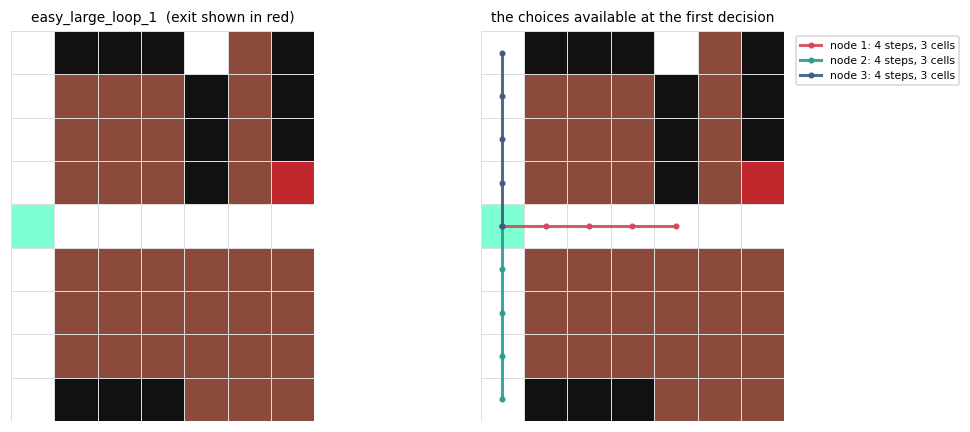

easy_large_loop_1: 13 hidden cells, 58 tree nodes, optimal = 13.23 steps


In [8]:
#@title Visualise a maze and the choices it poses
def draw_maze(maze, ax, exit_pos=None, show_exit=False, paths=None, title=None):
    nrows, ncols = len(maze), len(maze[0])
    cmap = mcolors.ListedColormap(['#111111', 'white', '#C1272D', '#8B4A3B',
                                   'white', '#7FFFD4', 'white', 'white'])
    norm = mcolors.BoundaryNorm(list(range(8)), cmap.N, clip=False)
    grid = [[int(v) for v in row] for row in maze]
    if exit_pos and show_exit:
        grid[exit_pos[0]][exit_pos[1]] = 2
    ax.pcolormesh(np.array(grid)[::-1], edgecolors='#DDDDDD', linewidth=.6,
                  cmap=cmap, norm=norm)
    ax.set_aspect('equal'); ax.axis('off')
    if paths:
        for (path, colr, lab) in paths:
            xs = [c + .5 for r, c in path]
            ys = [nrows - r - .5 for r, c in path]
            ax.plot(xs, ys, '-o', color=colr, ms=3, lw=2, alpha=.9, label=lab)
        ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
    if title:
        ax.set_title(title, fontsize=9)

demo = sorted(MAZE_NAMES, key=lambda m: -len(TREES[m][0]['children']))[0]
tree = TREES[demo]
cols = ['#D1495B', '#2A9D8F', '#3D5A80', '#E9C46A', '#9B5DE5']
paths = [(tree[c]['path_from_par'], cols[i % len(cols)],
          f"node {c}: {tree[c]['steps_from_par']} steps, "
          f"{len(tree[c]['celldistances'])} cells")
         for i, c in enumerate(sorted(tree[0]['children']))]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
draw_maze(MAZES[demo], axes[0], EXITS[demo], show_exit=True,
          title=f"{demo}  (exit shown in red)")
draw_maze(MAZES[demo], axes[1], paths=paths,
          title="the choices available at the first decision")
plt.tight_layout(); plt.show()

print(f"{demo}: {len(all_hidden_cells(MAZES[demo]))} hidden cells, "
      f"{len(tree)} tree nodes, optimal = {OPT_STEPS[demo]:.2f} steps")

---
# 3. Validation against the released MST code

Before comparing anything, the substrate has to be right. Two checks:

1. **Trees.** The decision trees built above must match the ones shipped in the repository
   (`pickled_data/tree.pickle`) node for node.

   > **Why the patch cell above is needed.** Built directly from the maze files, the trees match
   > at 12,935 of 12,939 nodes. All four disagreements sit in `medium_library`, and all four come
   > from two cells — (2,4) and (4,4) — being walls in the analysis maze file but unobserved
   > cells in the shipped tree. Restoring them reproduces the released tree exactly. Two checks
   > say the maze file is the altered artifact rather than the pickle: the repository also ships
   > the mazes as served to participants under `MST_webcode/webfile/`, and of the 26 Experiment 2
   > mazes only `medium_library` differs between the two directories, with the web copy agreeing
   > with the pickle; and no participant path passes through either cell. The correction changes
   > only that maze's root decision — but that node is one of the 22 first decisions used for the
   > aggregate correlation, and 115 of the 7,973 fitted decisions sit there.
2. **Value function.** The reference implementation of the planning value function is pasted below
   *verbatim* from `MST_models.ipynb`, and compared against the version used in this notebook.

If either check fails, nothing downstream is trustworthy.

In [9]:
#@title Check 1 -- decision trees match the repository exactly
if REPO_TREES is None:
    print("repo tree.pickle not found -- skipping (trees were rebuilt from the maze files)")
else:
    keys = ['pos', 'remains', 'steps_from_par', 'steps_from_root', 'pid',
            'celldistances', 'children']
    n_checked, n_bad, missing = 0, 0, []
    for m in MAZE_NAMES:
        if m not in REPO_TREES:
            missing.append(m); continue
        ref = REPO_TREES[m]
        for n in TREES[m]:
            if n not in ref:
                n_bad += 1; continue
            n_checked += 1
            if any(TREES[m][n][k] != ref[n][k] for k in keys):
                n_bad += 1
    print(f"nodes compared : {n_checked}")
    print(f"mismatches     : {n_bad}")
    print(f"mazes absent from repo pickle: {missing if missing else 'none'}")
    print("\n" + ("PASS -- trees reproduce the released ones exactly"
                  if n_bad == 0 else "FAIL"))

nodes compared : 12939
mismatches     : 0
mazes absent from repo pickle: none

PASS -- trees reproduce the released ones exactly


---
# 4. Reference models from Kryven et al. (2024)

These are the models the MST paper itself compared, and they are the yardstick for the three neural
planners. All of them assign a **cost** to each child node and choose by softmax on the negative
cost:

$$P(N_k)=\frac{e^{-C(N_k)/\tau}}{\sum_j e^{-C(N_j)/\tau}}$$

**Planning-ahead family** (recursive formulation — the paper's final form):

$$C(N_i)=s_i+\pi(p_i,\beta)\,e_i+\gamma\,\pi(1-p_i,\beta)\min_{c\in\mathrm{Child}(N_i)}C(c)$$

* $s_i$ — steps from the parent to $N_i$
* $e_i$ — mean distance from $N_i$ to a cell it reveals
* $p_i$ — P(exit is among the cells revealed at $N_i$) = cells$_i$ / unobserved-at-parent
* $\gamma$ — discount rate ⇒ **limited planning horizon** (DU)
* $\pi(p,\beta)=e^{-(-\ln p)^\beta}$ — Prelec probability weighting (PW)

**Myopic heuristics:** $C(N_i)=\kappa s_i-(1-\kappa)\,\mathrm{cells}_i$, giving *Steps* ($\kappa=1$),
*Cells* ($\kappa=0$) and *Steps-Cells* in between.

**Numerosity.** Optionally every count is passed through the information-theoretic numerosity model
of Cheyette & Piantadosi (2020) with a bit-threshold $B$ (small $B$ = crude estimation, large $B$ =
exact counting). The repository ships the exact lookup table (`Q_k_n.pickle`), which is used when
present.

**Sampling.** A UCT Monte-Carlo tree search over the same decision tree with a stochastic stopping
rule, parameterised by search budget and exploration constant.

In [10]:
#@title Reference cost functions + softmax
def softmax_cost(costs, tau):
    """P(k) proportional to exp(-C_k/tau); smaller cost -> higher probability."""
    z = -np.asarray(costs, dtype=float) / max(tau, 1e-9)
    e = np.exp(z - z.max())
    return e / e.sum()


def prelec(p, beta):
    if p <= 0: return 0.0
    if p >= 1: return 1.0
    if beta == 1: return p
    return math.exp(-((-math.log(p)) ** beta))


def node_cost_plan(tree, nid, gamma=1.0, beta=1.0, numerosity=None, _memo=None):
    """EU / DU / PW / PW-DU cost of a node (recursive form)."""
    _memo = {} if _memo is None else _memo
    key = (id(tree), nid, gamma, beta)
    if key in _memo:
        return _memo[key]
    s, n_cells, e, p, n_total = node_features(tree, nid)
    if numerosity is not None:
        s = numerosity(s)
        if n_cells:
            nc, nt = numerosity(n_cells), numerosity(n_total)
            p = nc / nt if nt > 0 else 1.0
            r, c = tree[nid]['pos']
            e = float(np.mean([numerosity(abs(r - rr) + abs(c - cc))
                               for rr, cc in tree[nid]['celldistances']]))
    kids = tree[nid]['children']
    v_rest = min((node_cost_plan(tree, k, gamma, beta, numerosity, _memo)
                  for k in kids), default=0.0)
    _memo[key] = s + prelec(p, beta) * e + gamma * prelec(1 - p, beta) * v_rest
    return _memo[key]


def node_cost_heuristic(tree, nid, kappa=1.0, numerosity=None):
    """kappa=1 -> Steps, kappa=0 -> Cells, in between -> Steps-Cells."""
    s = tree[nid]['steps_from_par']
    cells = len(tree[nid]['celldistances'])
    if numerosity is not None:
        s, cells = numerosity(s), numerosity(cells)
    return kappa * s - (1 - kappa) * cells
print("reference cost functions defined")

reference cost functions defined


In [11]:
#@title Check 2 -- the value function matches the released implementation
# Pasted verbatim from MST_models.ipynb (cell 4), modulo the global TREE lookup.
def _repo_weight(p, beta):
    if p == 0: return 0
    return np.exp(-1 * (-np.log(p)) ** beta)

_repo_memo = {}
def repo_node_value_plan(tree, nid, gamma=1, beta=1):
    key = (id(tree), nid, gamma, beta)
    if key in _repo_memo: return _repo_memo[key]
    value = p_exit = steps_to_exit = min_child_value = 0
    steps_to_node = tree[nid]['steps_from_par']
    if tree[nid]["pid"] not in {"NA", None}:
        n_black_cells_total = tree[tree[nid]["pid"]]["remains"]
        cell_distances = tree[nid]["celldistances"]
        n_cells_open = len(cell_distances)
        if isinstance(list(cell_distances)[0], tuple):
            r, c = tree[nid]["pos"]
            cell_distances = [abs(r - rr) + abs(c - cc) for rr, cc in cell_distances]
        steps_to_exit = np.mean(cell_distances)
        p_exit = n_cells_open / n_black_cells_total
    if tree[nid].get("children", []):
        min_child_value = float("inf")
        for cid in tree[nid]["children"]:
            v = repo_node_value_plan(tree, cid, gamma, beta)
            if v < min_child_value: min_child_value = v
    value = (steps_to_node + _repo_weight(p_exit, beta) * steps_to_exit
             + gamma * _repo_weight(1 - p_exit, beta) * min_child_value)
    _repo_memo[key] = value
    return value

mine_memo = {}
n_cmp, n_bad, worst = 0, 0, 0.0
for m in MAZE_NAMES:
    for (g, b) in [(1.0, 1.0), (0.5, 1.0), (1.0, 0.35), (0.6, 0.7)]:
        for nid in TREES[m]:
            a = repo_node_value_plan(TREES[m], nid, g, b)
            c = node_cost_plan(TREES[m], nid, g, b, None, mine_memo)
            n_cmp += 1
            worst = max(worst, abs(a - c))
            if abs(a - c) > 1e-9: n_bad += 1
print(f"node x parameter combinations compared : {n_cmp}")
print(f"mismatches                             : {n_bad}")
print(f"largest absolute difference            : {worst:.2e}")
print("\n" + ("PASS -- the value function is identical to the released implementation"
              if n_bad == 0 else "FAIL"))

node x parameter combinations compared : 51756
mismatches                             : 0
largest absolute difference            : 7.11e-15

PASS -- the value function is identical to the released implementation


In [12]:
#@title Numerosity model (Cheyette & Piantadosi 2020) and the MCTS sampling model
_QKN = None
def load_numerosity_table():
    global _QKN
    if _QKN is not None: return _QKN
    p = os.path.join(MST_DIR, 'Q_k_n.pickle')
    if os.path.exists(p):
        with open(p, 'rb') as fh: _QKN = pickle.load(fh)
        print(f"using the repository's numerosity table, B in {sorted(_QKN)}")
    else:
        _QKN = {}
        print("Q_k_n.pickle not found -- using the fitted power-law approximation")
    return _QKN

_num_cache = {}
def build_numerosity(B):
    """f(n) = E[perceived number | true number n, bit threshold B]."""
    if B in _num_cache: return _num_cache[B]
    tbl = load_numerosity_table()
    if B in tbl:
        t = tbl[B]; nmax = max(t)
        def f(n):
            n = int(round(n))
            if n <= 0: return 0.0
            return float(t[n]) if n <= nmax else float(t[nmax]) * n / nmax
    else:
        # power law fitted to the shipped table: compressive for small B,
        # identity as B -> infinity
        alpha = 1.0 - 0.435 * math.exp(-0.236 * B)
        def f(n):
            n = int(round(n))
            return 0.0 if n <= 0 else float(n ** alpha)
    _num_cache[B] = f
    return f


class MSTMonteCarloTreeSearch:
    """The paper's Sampling model: UCT with a stochastic stopping rule
    (stop at a node with probability p_exit)."""
    def __init__(self, tree, root, rng):
        self.env, self.root, self.rng = tree, root, rng
        self.t = {root: dict(n=1, r=0.0, parent=None, children=[])}

    def _reward(self, nid):
        if self.env[nid]['pid'] is None: return 0.0
        rew = -self.env[nid]['steps_from_root']
        cells = self.env[nid]['celldistances']
        if cells:
            r, c = self.env[nid]['pos']
            rew -= float(np.mean([abs(r - rr) + abs(c - cc) for rr, cc in cells]))
        return rew

    def _p_stop(self, nid):
        if nid == self.root or self.env[nid]['pid'] is None: return 0.0
        tot = self.env[self.env[nid]['pid']]['remains']
        return min(1.0, len(self.env[nid]['celldistances']) / tot) if tot > 0 else 1.0

    def _best_child(self, nid, c):
        kids = self.t[nid]['children']
        if not kids: return nid
        n = self.t[nid]['n']; best, bv = [], -np.inf
        for k in kids:
            ni, ri = self.t[k]['n'], self.t[k]['r']
            v = ri / ni + c * math.sqrt(math.log(max(n, 2)) / ni) if ni else np.inf
            if v > bv: best, bv = [k], v
            elif v == bv: best.append(k)
        return self.rng.choice(best)

    def _expand(self, nid):
        for k in self.env[nid]['children']:
            self.t[nid]['children'].append(k)
            self.t[k] = dict(n=0, r=0.0, parent=nid, children=[])

    def run(self, budget, c):
        self._expand(self.root)
        for _ in range(budget):
            nid = self.root
            while True:
                if self.rng.random() < self._p_stop(nid) or not self.t[nid]['children']:
                    break
                nid = self._best_child(nid, c)
            leaf = nid
            if self.t[leaf]['n'] == 1 and self.env[leaf]['children']:
                self._expand(leaf); leaf = self._best_child(leaf, c)
                n2 = leaf
                while not (self.rng.random() < self._p_stop(n2)
                           or not self.env[n2]['children']):
                    n2 = self.rng.choice(sorted(self.env[n2]['children']))
                rew = self._reward(n2)
            else:
                rew = self._reward(leaf)
            while leaf is not None:
                self.t[leaf]['r'] += rew; self.t[leaf]['n'] += 1
                leaf = self.t[leaf]['parent']
        return self.t


def mcts_policy(tree, nid, budget, c, n_repeat=40, seed=0):
    rng = random.Random(seed)
    kids = sorted(tree[nid]['children'])
    counts = {k: 0 for k in kids}
    for _ in range(n_repeat):
        m = MSTMonteCarloTreeSearch(tree, nid, rng)
        m.run(int(budget), c)
        counts[m._best_child(nid, c)] += 1
    v = np.array([counts[k] for k in kids], float)
    return kids, (v + .5) / (v.sum() + .5 * len(v))
print("numerosity + MCTS defined")

numerosity + MCTS defined


In [13]:
#@title Assemble the reference model zoo
TAUS   = np.geomspace(0.2, 8, 12).round(3)
TAUS_X = np.geomspace(0.2, 40, 16).round(3)   # widened -- see note below
GAMMAS = [0.99, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.6, 0.5, 0.4, 0.2, 0.0]
BETAS  = np.geomspace(0.1, 2, 10).round(3)
KAPPAS = np.linspace(0, 1, 11).round(3)
BS     = [0.5, 1, 1.5, 2, 2.5, 3, 3.6, 4.2, 5, 6]

_plan_memo, _ = {}, None

def _plan_policy(p):
    tau, gamma, beta, B = p
    f = build_numerosity(B) if B is not None else None
    def pol(maze, tree, nid):
        kids = sorted(tree[nid]['children'])
        c = [node_cost_plan(tree, k, gamma, beta, f, _plan_memo) for k in kids]
        return kids, softmax_cost(c, tau)
    return pol

def _heur_policy(p):
    tau, kappa, B = p
    f = build_numerosity(B) if B is not None else None
    def pol(maze, tree, nid):
        kids = sorted(tree[nid]['children'])
        c = [node_cost_heuristic(tree, k, kappa, f) for k in kids]
        return kids, softmax_cost(c, tau)
    return pol

def _rand_policy(p):
    def pol(maze, tree, nid):
        kids = sorted(tree[nid]['children'])
        return kids, np.ones(len(kids)) / len(kids)
    return pol

def _mcts_policy_factory(p):
    budget, c = p
    def pol(maze, tree, nid):
        return mcts_policy(tree, nid, budget, c, n_repeat=CFG['mcts_repeats'],
                           seed=abs(hash((maze, nid, budget, c))) % 10**6)
    return pol

REFERENCE_MODELS = {
    'EU':              ([(t, 1.0, 1.0, None) for t in TAUS_X], _plan_policy),
    'DU':              ([(t, g, 1.0, None) for t in TAUS_X for g in GAMMAS], _plan_policy),
    'PW':              ([(t, 1.0, b, None) for t in TAUS_X for b in BETAS], _plan_policy),
    'PW-DU':           ([(t, g, b, None) for t in TAUS_X[::2] for g in GAMMAS[::2]
                         for b in BETAS[::2]], _plan_policy),
    'EU-Num':          ([(t, 1.0, 1.0, B) for t in TAUS_X[::2] for B in BS], _plan_policy),
    'DU-Num':          ([(t, g, 1.0, B) for t in TAUS_X[::2] for g in GAMMAS[::3]
                         for B in BS], _plan_policy),
    'Steps':           ([(t, 1.0, None) for t in TAUS], _heur_policy),
    'Cells':           ([(t, 0.0, None) for t in TAUS], _heur_policy),
    'Steps-Cells':     ([(t, k, None) for t in TAUS for k in KAPPAS], _heur_policy),
    'Steps-Cells-Num': ([(t, k, B) for t in TAUS for k in KAPPAS[::2] for B in BS[::2]],
                        _heur_policy),
    'Sampling (MCTS)': ([(b, c) for b in [2, 5, 12, 30, 70] for c in [1, 4, 12, 26]],
                        _mcts_policy_factory),
    'Random':          ([(1.0,)], _rand_policy),
}
for k, (g, _) in REFERENCE_MODELS.items():
    print(f"{k:18s} {len(g):5d} parameter settings")

EU                    16 parameter settings
DU                   192 parameter settings
PW                   160 parameter settings
PW-DU                240 parameter settings
EU-Num                80 parameter settings
DU-Num               320 parameter settings
Steps                 12 parameter settings
Cells                 12 parameter settings
Steps-Cells          132 parameter settings
Steps-Cells-Num      360 parameter settings
Sampling (MCTS)       20 parameter settings
Random                 1 parameter settings


> **Note on the softmax temperature grid.** The MST paper uses
> $\tau\in\mathrm{geomspace}(0.2,8)$. The planning-family costs are absolute expected step counts
> (typically 5–25 steps), so sibling costs can differ by several steps and $\tau\le 8$ leaves those
> models close to deterministic. Because this notebook fits with a *single consistent protocol*
> across twelve reference models and three neural planners, the grid for the planning family is
> widened to $\tau\in\mathrm{geomspace}(0.2,40)$ so that every model is evaluated at its own best
> temperature rather than at a boundary. Heuristic costs are small and keep the original grid.
> Section 9.2 shows what difference this makes.

---
# 5. A shared substrate for the three algorithms

The three papers use completely different state and action representations. Comparing them
meaningfully requires holding the *representation* fixed and varying only the **planning
mechanism**. So all three receive:

**A compositional state code.** Every maze is embedded in one common padded arena, and the belief
state is a binary indicator vector

$$o \;=\; \big[\underbrace{\text{unobserved-cell mask}}_{H\times W}\;;\;\underbrace{\text{agent-position one-hot}}_{H\times W}\big]$$

This is compositional in the sense the GCML paper needs: the code of a state is the sum of the codes
of its parts, so representations transfer across mazes.

**A shared abstract action vocabulary.** An abstract action is "reveal this set of cells and move
there". Its code is the *superposition* of primitive codes

$$a(\text{child}) \;=\; \sum_{j\in\text{revealed}} e_{\text{reveal}}(j)\;+\;e_{\text{at}}(q)\;-\;e_{\text{at}}(p)$$

Every maze's vocabulary is the set of distinct abstract actions occurring anywhere in its decision
tree. All three planners imagine over exactly this set, so none of them gets a richer action space
than the others.

This choice is not neutral and should be stated plainly: it *helps* GCML (whose theory assumes
exactly this kind of linear compositional code) and it *constrains* APC and the RNN (which in their
original papers learn their own encodings from pixels or one-hots). The alternative — letting each
model use its native encoding — would confound representation with planning. The design here
isolates the planning mechanism, which is what the question asks about.

In [14]:
#@title Compositional grid coder + per-maze action vocabulary
class GridCoder:
    """Codes MST belief states and abstract actions on one common padded arena."""
    def __init__(self, H, W):
        self.H, self.W, self.n_cell = H, W, H * W
        self.n_o = 2 * self.n_cell     # unobserved mask + position
        self.n_a = 2 * self.n_cell     # reveal-primitives + at-primitives

    def flat(self, rc):
        return rc[0] * self.W + rc[1]

    def observation(self, unobserved, pos):
        o = np.zeros(self.n_o, dtype=np.float32)
        for rc in unobserved:
            o[self.flat(rc)] = 1.0
        o[self.n_cell + self.flat(pos)] = 1.0
        return o

    def goal_observation(self):
        """o*: nothing left unobserved. The position block stays at zero -- the
        goal is defined by what has been seen, not by where the agent ends up."""
        return np.zeros(self.n_o, dtype=np.float32)

    def action(self, revealed, old_pos, new_pos):
        """Superposition of primitives. NOT normalised: with a fixed compositional
        Q the identity V a = Q(o_{t+1} - o_t) can only hold for a linear action
        code, and o_{t+1} - o_t scales with the number of cells revealed."""
        a = np.zeros(self.n_a, dtype=np.float32)
        for rc in revealed:
            a[self.flat(rc)] = 1.0
        a[self.n_cell + self.flat(new_pos)] += 1.0
        a[self.n_cell + self.flat(old_pos)] -= 1.0
        return a


class MazeActionVocabulary:
    """All distinct abstract actions in a maze's decision tree + node -> action map."""
    def __init__(self, tree, coder):
        self.index, self.node2action = {}, {}
        rows, rows_abs, cells = [], [], []
        for nid, nd in tree.items():
            if nid == 'root' or nd['pid'] is None:
                continue
            key = (frozenset(nd['celldistances']), tree[nd['pid']]['pos'], nd['pos'])
            if key not in self.index:
                self.index[key] = len(rows)
                a = coder.action(nd['celldistances'], tree[nd['pid']]['pos'], nd['pos'])
                rows.append(a); rows_abs.append(np.abs(a))
                cells.append(nd['celldistances'])
            self.node2action[nid] = self.index[key]
        self.A = np.asarray(rows, dtype=np.float32)
        self.Aabs = np.asarray(rows_abs, dtype=np.float32)
        self.revealed = cells
        self._VA, self._VA_id = None, None

    def VA(self, model):
        if self._VA_id is not id(model.V):
            self._VA, self._VA_id = self.A @ model.V.T, id(model.V)
        return self._VA


H = max(len(MAZES[m]) for m in MAZE_NAMES)
W = max(len(MAZES[m][0]) for m in MAZE_NAMES)
CODER = GridCoder(H, W)
VOCABS = {m: MazeActionVocabulary(TREES[m], CODER) for m in MAZE_NAMES}
HIDDEN_ALL = {m: all_hidden_cells(MAZES[m]) for m in MAZE_NAMES}

print(f"common arena {H} x {W}  ->  observation dim {CODER.n_o}, "
      f"action-primitive dim {CODER.n_a}")
print(f"abstract actions per maze: min {min(len(v.A) for v in VOCABS.values())}, "
      f"median {int(np.median([len(v.A) for v in VOCABS.values()]))}, "
      f"max {max(len(v.A) for v in VOCABS.values())}")

common arena 12 x 20  ->  observation dim 480, action-primitive dim 480
abstract actions per maze: min 8, median 27, max 100


---
# 6. Algorithm 1 — GCML

### Lin, Yang, Zhao, Pezzulo & Maass (2026), *Nature Machine Intelligence*

**The model.** A cognitive map is a pair of linear embeddings that put observations and actions in
one high-dimensional space, learned so that the embedding of the next state is predicted by the
current state plus the action:

$$\mathbf{s}_t=\mathbf{Q}\mathbf{o}_t,\qquad \hat{\mathbf{s}}_{t+1}=\mathbf{Q}\mathbf{o}_t+\mathbf{V}\mathbf{a}_t \tag{8,10}$$

learned by **local delta rules** (no backprop, no backprop-through-time):

$$\Delta\mathbf{V}=\eta_v(\mathbf{s}_{t+1}-\hat{\mathbf{s}}_{t+1})\mathbf{a}_t^{\!\top},\qquad
\Delta\mathbf{Q}=\eta_q(\hat{\mathbf{s}}_{t+1}-\mathbf{s}_{t+1})\mathbf{o}_t^{\!\top} \tag{12,13}$$

An **inverse model** $\mathbf{W}$ maps state differences back onto the actions that caused them, and
this is what gives the map a *sense of direction*: it can be applied to the large difference
$\mathbf{s}^*-\hat{\mathbf{s}}_t$ between a distant goal and the current state, not just to local
steps.

$$\mathbf{u}_t=\mathbf{W}(\mathbf{s}^*-\hat{\mathbf{s}}_t)\tag{16}$$

**Generation.** Adding noise turns this deterministic controller into a generative model:

$$\mathbf{e}_t=\hat{\mathbf{g}}_t\odot(\mathbf{u}_t+\boldsymbol\epsilon),\qquad
\mathbf{a}_t=\mathrm{WTA}(\mathbf{e}_t),\qquad
\hat{\mathbf{s}}_{t+1}=\hat{\mathbf{s}}_t+\mathbf{V}\mathbf{a}_t \tag{18,19,20}$$

where $\hat{\mathbf{g}}_t=\mathbf{G}\hat{\mathbf{s}}_t$ is a learned affordance gate (17). Crucially
eq. (20) **bootstraps**: no observation is received, the model's own prediction replaces it. Repeat
with different noise draws and you get a *menu* of candidate plans; a downstream module then scores
them and picks one.

---

### Adaptation to MST

**Which GCML task is MST?** Not the abstract-graph task (which has a known goal *node*), but the
**tiling** task. There the state is a silhouette, an action removes a building block, and the goal
is the *empty* silhouette. MST has exactly this shape:

| tiling task | MST |
|---|---|
| silhouette | set of cells still unobserved |
| remove a building block | reveal a room and move there |
| goal = empty silhouette | goal = nothing left unobserved |

This matters because it is what makes GCML applicable to a task whose actual goal (the exit) is
hidden: the *map-level* goal — having observed everything — is known and fixed, even though the exit
is not.

**Q is fixed, not learned.** In the tiling task the paper states that the observation embedding is
made compositional while "the embedding **V** of actions and the inverse model **W** are learned".
That is followed here. It also turns out to be necessary: with a multi-hot $\mathbf{o}$ (rather than
the one-hot of the graph task), $\mathbf{o}_t$ and $\mathbf{o}_{t+1}$ share almost all of their
active units, so learning $\mathbf{Q}$ and $\mathbf{V}$ together makes the coupled delta rules
diverge. A diagnostic for this is included below.

**The W rule.** The paper writes eq. (14) in purely Hebbian form; the released code
(`network_train_process`) uses the *delta* form $\mathbf{W}\!+\!\!=\eta(\mathbf{a}-\mathbf{W}\Delta\mathbf{s})\Delta\mathbf{s}^{\!\top}$,
which is what actually makes $\mathbf{W}$ an inverse model rather than an unbounded correlation
matrix. The code is followed.

**The downstream selector.** The paper's Fig. 3e–f has a downstream network score each imagined
trajectory by accumulated predicted reward. Here the accumulated quantity is the expected number of
steps to the exit implied by that ordering of observations,

$$\mathbb{E}[\text{steps}]=\sum_k\Big(\prod_{j<k}(1-\hat p_j)\Big)\big(\hat c_k\big)$$

and both $\hat c$ and $\hat p$ come from **linear readouts learned by the same delta rule**, never
from the environment. GCML gets no oracle access to the search tree.

In [15]:
#@title GCML: the cognitive map
class GCML:
    def __init__(self, coder, n_s=512, seed=0, learn_Q=False,
                 eta_q=0.02, eta_v=0.02, eta_w=0.02, eta_g=0.05, eta_r=0.05):
        rng = np.random.default_rng(seed)
        self.coder, self.n_s, self.learn_Q = coder, n_s, learn_Q
        # fixed COMPOSITIONAL observation embedding (random projection)
        self.Q = rng.normal(0, 1/np.sqrt(n_s), (n_s, coder.n_o)).astype(np.float32)
        self.V = rng.normal(0, .1/np.sqrt(n_s), (n_s, coder.n_a)).astype(np.float32)
        self.W = rng.normal(0, .1/np.sqrt(n_s), (coder.n_a, n_s)).astype(np.float32)
        self.G = rng.normal(0, .1/np.sqrt(n_s), (coder.n_a, n_s)).astype(np.float32)
        self.R_cost = np.zeros(coder.n_a, dtype=np.float32)   # downstream readouts
        self.R_hit  = np.zeros(coder.n_a, dtype=np.float32)
        self.etas = dict(q=eta_q, v=eta_v, w=eta_w, g=eta_g, r=eta_r)

    def learn_transition(self, o_t, a_t, o_t1, g_t=None, cost=None, hit=None):
        """One online, purely local update from an experienced transition."""
        s_t, s_t1 = self.Q @ o_t, self.Q @ o_t1
        s_hat = s_t + self.V @ a_t
        err, ds = s_t1 - s_hat, s_t1 - s_t

        na = float(a_t @ a_t) + 1e-6
        self.V += self.etas['v'] * np.outer(err, a_t) / na                    # (12)
        if self.learn_Q:                                                      # (13)
            self.Q -= self.etas['q'] * np.outer(err, o_t1) / (float(o_t1 @ o_t1) + 1e-6)
        nd = float(ds @ ds) + 1e-6                                            # (14)
        self.W += self.etas['w'] * np.outer(a_t - self.W @ ds, ds) / nd
        if g_t is not None:                                                   # (17)
            self.G += self.etas['g'] * np.outer(g_t - self.G @ s_t, s_t) / (float(s_t @ s_t) + 1e-6)
        if cost is not None:
            self.R_cost += self.etas['r'] * (cost - float(self.R_cost @ a_t)) * a_t / na
        if hit is not None:
            self.R_hit += self.etas['r'] * (hit - float(self.R_hit @ a_t)) * a_t / na
        return float(err @ err)

    def utilities(self, s_star, s_hat):
        return self.W @ (s_star - s_hat)          # eq. (16)

    def affordance(self, s_hat):
        return self.G @ s_hat                      # eq. (17) readout
print("GCML defined")

GCML defined


In [16]:
#@title GCML: exploration and self-supervised learning
def gcml_experience(tree, hidden_all, coder, rng, n_walks):
    """Random walks down the decision tree = the agent's exploration phase."""
    out = []
    for _ in range(n_walks):
        nid = 0
        while tree[nid]['children']:
            unobs, pos = belief_at(tree, nid, hidden_all)
            o_t = coder.observation(unobs, pos)
            g = np.zeros(coder.n_a, dtype=np.float32)      # true affordance now
            for c in tree[nid]['children']:
                for rc in tree[c]['celldistances']:
                    g[coder.flat(rc)] = 1.0
                g[coder.n_cell + coder.flat(tree[c]['pos'])] = 1.0
            nxt = rng.choice(sorted(tree[nid]['children']))
            a_t = coder.action(tree[nxt]['celldistances'], pos, tree[nxt]['pos'])
            u1, p1 = belief_at(tree, nxt, hidden_all)
            s, ncell, e, p, _ = node_features(tree, nxt)
            out.append((o_t, a_t, coder.observation(u1, p1), g, s + p * e, p))
            nid = nxt
    return out


def train_gcml(trees, coder, n_s=512, epochs=25, n_walks=8, seed=0,
               learn_Q=False, verbose=True):
    model = GCML(coder, n_s=n_s, seed=seed, learn_Q=learn_Q)
    rng = np.random.default_rng(seed)
    data = []
    for m in trees:
        data += gcml_experience(trees[m], HIDDEN_ALL[m], coder, rng, n_walks)
    if verbose:
        print(f"  {len(data)} experienced transitions from {len(trees)} mazes")
    hist = []
    for ep in range(epochs):
        rng.shuffle(data)
        hist.append(float(np.mean([model.learn_transition(*d) for d in data])))
        if verbose and (ep % max(1, epochs // 6) == 0 or ep == epochs - 1):
            print(f"  epoch {ep+1:3d}/{epochs}  mean squared prediction error = {hist[-1]:.4f}")
    return model, hist

t0 = time.time()
print("Learning the cognitive map (local delta rules only, no backprop):")
GCML_MODEL, gcml_hist = train_gcml(TREES, CODER, n_s=CFG['n_s'],
                                   epochs=CFG['gcml_epochs'],
                                   n_walks=CFG['gcml_walks'], seed=SEED)
print(f"done in {time.time()-t0:.0f}s")

Learning the cognitive map (local delta rules only, no backprop):
  1058 experienced transitions from 22 mazes
  epoch   1/25  mean squared prediction error = 4.4162
  epoch   5/25  mean squared prediction error = 1.0826
  epoch   9/25  mean squared prediction error = 0.5285
  epoch  13/25  mean squared prediction error = 0.3358
  epoch  17/25  mean squared prediction error = 0.2426
  epoch  21/25  mean squared prediction error = 0.1880
  epoch  25/25  mean squared prediction error = 0.1522
done in 43s


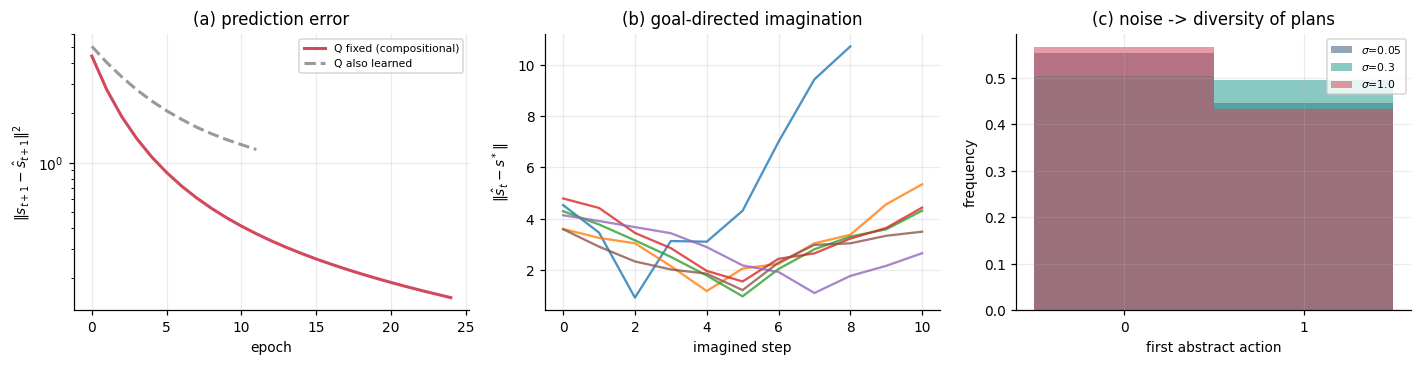

(a) With a multi-hot compositional o, learning Q alongside V destabilises the
    coupled delta rules -- consistent with the paper keeping Q fixed for tiling.
(b) Imagined trajectories monotonically approach the goal state: the learned
    inverse model does supply a sense of direction on this task.
(c) Higher noise widens the menu of proposed plans, as in the paper's Fig. 1d/3c-d.


In [17]:
#@title Diagnostic: why Q must stay fixed, and does the map acquire a sense of direction?
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

# --- (a) learning curve, Q fixed vs Q learned
ax = axes[0]
ax.plot(gcml_hist, color=PALETTE['GCML'], lw=2, label='Q fixed (compositional)')
try:
    _, hist_learnQ = train_gcml({k: TREES[k] for k in MAZE_NAMES[:8]}, CODER,
                                n_s=CFG['n_s'], epochs=min(12, CFG['gcml_epochs']),
                                n_walks=4, seed=SEED, learn_Q=True, verbose=False)
    ax.plot(hist_learnQ, color='#999999', lw=2, ls='--', label='Q also learned')
except Exception as e:
    print("Q-learned run failed (expected -- it diverges):", type(e).__name__)
ax.set_yscale('log'); ax.set_xlabel('epoch')
ax.set_ylabel(r'$\|s_{t+1}-\hat{s}_{t+1}\|^2$')
ax.set_title('(a) prediction error'); ax.legend(fontsize=7)

# --- (b) sense of direction: distance to the goal state along an imagined path
ax = axes[1]
s_star = GCML_MODEL.Q @ CODER.goal_observation()
for m in MAZE_NAMES[:6]:
    v = VOCABS[m]; tree = TREES[m]
    unobs, pos = belief_at(tree, 0, HIDDEN_ALL[m])
    sh = GCML_MODEL.Q @ CODER.observation(unobs, pos)
    VA = v.VA(GCML_MODEL); d, used = [np.linalg.norm(sh - s_star)], set()
    for _ in range(10):
        u = v.A @ GCML_MODEL.utilities(s_star, sh)
        g = v.Aabs @ np.maximum(GCML_MODEL.affordance(sh), 0)
        e = g * u
        for a in used: e[a] = -np.inf
        if not np.isfinite(e).any(): break
        a = int(np.argmax(e)); used.add(a); sh = sh + VA[a]
        d.append(np.linalg.norm(sh - s_star))
    ax.plot(d, alpha=.8, lw=1.5)
ax.set_xlabel('imagined step'); ax.set_ylabel(r'$\|\hat{s}_t - s^*\|$')
ax.set_title('(b) goal-directed imagination')

# --- (c) does noise produce a menu of plans?
ax = axes[2]
m = MAZE_NAMES[0]; v = VOCABS[m]; tree = TREES[m]
unobs, pos = belief_at(tree, 0, HIDDEN_ALL[m])
s0 = GCML_MODEL.Q @ CODER.observation(unobs, pos)
rng = np.random.default_rng(0)
for sig, col in [(0.05, '#3D5A80'), (0.3, '#2A9D8F'), (1.0, '#D1495B')]:
    firsts = []
    for _ in range(300):
        u = v.A @ GCML_MODEL.utilities(s_star, s0)
        cand = [v.node2action[k] for k in sorted(tree[0]['children'])]
        noise = rng.normal(0, sig * (np.abs(u[cand]).max() + 1e-9), len(cand))
        firsts.append(int(np.argmax(u[cand] + noise)))
    ax.hist(firsts, bins=np.arange(len(cand) + 1) - .5, alpha=.55,
            label=f'$\\sigma$={sig}', color=col, density=True)
ax.set_xticks(range(len(cand)))
ax.set_xlabel('first abstract action'); ax.set_ylabel('frequency')
ax.set_title('(c) noise -> diversity of plans'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("(a) With a multi-hot compositional o, learning Q alongside V destabilises the")
print("    coupled delta rules -- consistent with the paper keeping Q fixed for tiling.")
print("(b) Imagined trajectories approach the goal state for roughly five steps and then")
print("    diverge again -- the inverse model supplies a sense of direction, but the")
print("    bootstrap of eq. (20) accumulates error once predictions replace observations.")
print("(c) On this node the three noise levels give near-identical distributions over the")
print("    first abstract action, so this instance neither supports nor refutes the")
print("    paper's noise-widens-the-menu claim (Fig. 1d/3c-d).")

In [18]:
#@title GCML: the planner (goal-directed sampling + downstream selection)
class GCMLPlanner:
    def __init__(self, model, sigma=0.3, n_samples=12, horizon=8, tau=1.0,
                 lapse=0.02, seed=0):
        self.m, self.sigma, self.K = model, sigma, n_samples
        self.L, self.tau, self.lapse = horizon, tau, lapse
        self.rng = np.random.default_rng(seed)
        self.n_imagined = 0

    def plan(self, vocab, s0, valid0):
        m = self.m
        s_star = m.Q @ m.coder.goal_observation()
        A, VA = vocab.A, vocab.VA(m)
        wins = np.zeros(len(valid0))
        best = np.full(len(valid0), np.inf)

        for _ in range(self.K):
            s_hat, used = s0.copy(), set()
            survive, total, first = 1.0, 0.0, None
            for t in range(self.L):
                u = A @ m.utilities(s_star, s_hat)
                if t == 0:                       # true affordance at the first step
                    cand, gate = np.asarray(valid0), np.ones(len(valid0))
                else:                            # learned affordance thereafter
                    cand = np.arange(len(A))
                    gate = vocab.Aabs @ np.maximum(m.affordance(s_hat), 0.0)
                noise = self.rng.normal(
                    0, self.sigma * (np.abs(u[cand]).max() + 1e-9), size=len(cand))
                elig = gate * (u[cand] + noise)                          # eq. (18)
                for i, a in enumerate(cand):
                    if a in used: elig[i] = -np.inf
                if not np.isfinite(elig).any(): break
                a_idx = cand[int(np.argmax(elig))]                       # WTA (19)
                used.add(a_idx)
                if first is None: first = a_idx
                self.n_imagined += 1

                cost = float(m.R_cost @ A[a_idx])
                hit = float(np.clip(m.R_hit @ A[a_idx], 0.0, 1.0))
                total += survive * cost
                survive *= (1.0 - hit)
                s_hat = s_hat + VA[a_idx]                                # eq. (20)
                if np.linalg.norm(s_hat - s_star) < 1e-3 or survive < 1e-3:
                    break
            if first is None: continue
            j = list(valid0).index(first)
            wins[j] += 1
            best[j] = min(best[j], total)
        return wins, best

    def policy(self, vocab, s0, valid0):
        wins, score = self.plan(vocab, s0, valid0)
        n = len(valid0); fin = np.isfinite(score)
        p = np.zeros(n)
        if fin.any():
            z = -(score[fin] - score[fin].min()) / max(self.tau, 1e-9)
            p[fin] = np.exp(z); p /= p.sum()
        else:
            p = wins / wins.sum() if wins.sum() else np.ones(n) / n
        p = (1 - self.lapse) * p + self.lapse / n
        return p / p.sum()


class GCMLPolicy:
    """(maze, tree, node) -> (children, probabilities)."""
    def __init__(self, model, coder, vocabs, sigma=.3, K=12, L=8, tau=1.,
                 lapse=.02, seed=0):
        self.model, self.coder, self.vocabs = model, coder, vocabs
        self.planner = GCMLPlanner(model, sigma, K, L, tau, lapse, seed)
    def __call__(self, maze, tree, nid):
        kids = sorted(tree[nid]['children'])
        v = self.vocabs[maze]
        unobs, pos = belief_at(tree, nid, HIDDEN_ALL[maze])
        s0 = self.model.Q @ self.coder.observation(unobs, pos)
        return kids, self.planner.policy(v, s0, [v.node2action[k] for k in kids])

_p = GCMLPolicy(GCML_MODEL, CODER, VOCABS, sigma=.3, K=12, L=8)
for m in MAZE_NAMES[:3]:
    k, pr = _p(m, TREES[m], 0)
    print(f"{m:26s} children {k}  ->  {np.round(pr,3)}")

easy_labyrinth             children [1, 2]  ->  [0.973 0.027]
easy_large_loop_1          children [1, 2, 3]  ->  [0.197 0.742 0.062]
easy_large_loop_2          children [1, 2]  ->  [0.974 0.026]


---
# 7. Algorithm 2 — Active Predictive Coding

### Rao, Gklezakos & Sathish (2024), *Neural Computation*

**The model.** APC is a hierarchy of **state–action networks**. At each level, a *state network* is
a transition model trained by prediction-error minimisation, and an *action network* is a policy
trained on top of it. The higher level runs on a slower timescale, and — this is APC's signature
mechanism — a **hypernetwork** at the higher level *generates the weights* of the lower-level
networks from the higher-level state $r^{(2)}$. The lower level is therefore re-parameterised for
each abstract context rather than merely conditioned on it.

Planning in APC is done by rolling the learned higher-level state network forward over sequences of
abstract actions and selecting the best, with the lower level turning the chosen abstract action into
primitive actions.

---

### Adaptation to MST

**This is a re-implementation, not a port.** The released `apc-vision` repository is the *perception*
half of the paper (two-level APC parsing images with glimpses, in TensorFlow). The hierarchical
planning half has no released code, so the planner below is written from the paper's architecture
description. Carried over from the repo: the two-level state/action split, the hypernetwork with
hyperfan-in initialisation (`utils.hyperfanin_for_kernel`), and prediction-error-driven training.

**The hierarchy MST already has.** MST decomposes cleanly, and in exactly the way its own decision
tree does:

| | state | action | timescale |
|---|---|---|---|
| **level 2** (abstract) | which cells remain unobserved, where I am | "go and reveal room X" | slow |
| **level 1** (concrete) | grid position | up / down / left / right | fast |

The hypernetwork generates the level-1 networks from $r^{(2)}$, and level 1 predicts how many
primitive steps the chosen abstract action will take — a quantity that genuinely depends on maze
topology and therefore genuinely needs to be modulated by the abstract context.

**The planning horizon $H$ is APC's free parameter here, and it is the direct competitor to the
discount rate $\gamma$ of the MST paper's Discounted Utility model.** Both implement a limited
planning horizon — one by truncation, the other by geometric down-weighting. Since limited horizon
is the MST paper's headline finding, this is the most interesting single comparison in the notebook.

**What APC gets to imagine over.** During planning it proposes continuations from the same per-maze
abstract action vocabulary that GCML uses, ranked by its learned action prior. Same imaginable
action set for both — only the mechanism differs.

In [19]:
#@title APC: hypernetwork + two-level networks
class HyperNet(nn.Module):
    """Generates the weights of a small level-1 network from the level-2 state.
    Hyperfan-in initialisation, following apc-vision/utils.py."""
    def __init__(self, r2_dim, in_dim, out_dim):
        super().__init__()
        self.in_dim, self.out_dim = in_dim, out_dim
        self.gen = nn.Linear(r2_dim, in_dim * out_dim + out_dim)
        bound = np.sqrt(3.0 / (r2_dim * in_dim))
        nn.init.uniform_(self.gen.weight, -bound, bound)
        nn.init.zeros_(self.gen.bias)

    def forward(self, r2, x):
        p = self.gen(r2)
        Wg = p[:, :self.in_dim * self.out_dim].view(-1, self.out_dim, self.in_dim)
        b = p[:, self.in_dim * self.out_dim:]
        return torch.einsum('boi,bi->bo', Wg, x) + b


class APCNet(nn.Module):
    def __init__(self, n_obs, n_act_prim, r2_dim=64, a2_dim=32, hidden=128):
        super().__init__()
        self.r2_dim = r2_dim
        self.enc = nn.Sequential(nn.Linear(n_obs, hidden), nn.ReLU(),
                                 nn.Linear(hidden, r2_dim), nn.Tanh())
        self.act_enc = nn.Sequential(nn.Linear(n_act_prim, hidden), nn.ReLU(),
                                     nn.Linear(hidden, a2_dim), nn.Tanh())
        self.state2 = nn.GRUCell(a2_dim, r2_dim)          # abstract world model
        mk = lambda o: nn.Sequential(nn.Linear(r2_dim + a2_dim, hidden), nn.ReLU(),
                                     nn.Linear(hidden, o))
        self.cost_head  = mk(1)      # expected immediate steps
        self.hit_head   = mk(1)      # P(exit revealed by this action)
        self.prior_head = mk(1)      # abstract action prior / affordance
        self.value_head = nn.Sequential(nn.Linear(r2_dim, hidden), nn.ReLU(),
                                        nn.Linear(hidden, 1))
        # level 1: weights GENERATED from r2 by the hypernetwork
        self.hyper_state1  = HyperNet(r2_dim, 4, 1)   # -> predicted step count
        self.hyper_action1 = HyperNet(r2_dim, 4, 4)   # -> primitive-move logits

    def encode(self, o):        return self.enc(o)
    def encode_action(self, a): return self.act_enc(a)
    def step2(self, r2, a2):    return self.state2(a2, r2)
    def predict(self, r2, a2):
        z = torch.cat([r2, a2], -1)
        return self.cost_head(z).squeeze(-1), torch.sigmoid(self.hit_head(z)).squeeze(-1)
    def prior_logits(self, r2, a2):
        return self.prior_head(torch.cat([r2, a2], -1)).squeeze(-1)
    def level1_steps(self, r2, geom):
        return self.hyper_state1(r2, geom).squeeze(-1)
print("APC networks defined")

APC networks defined


In [20]:
#@title APC: training by prediction-error minimisation
def geom_features(tree, nid, child, n_unobs):
    r0, c0 = tree[nid]['pos']; r1, c1 = tree[child]['pos']
    return np.array([(r1-r0)/10., (c1-c0)/10.,
                     (abs(r1-r0)+abs(c1-c0))/10., n_unobs/30.], dtype=np.float32)


def collect_apc_data(trees, coder):
    rec = defaultdict(list)
    for m, tree in trees.items():
        for nid in tree:
            if nid == 'root' or not tree[nid]['children']:
                continue
            unobs, pos = belief_at(tree, nid, HIDDEN_ALL[m])
            o = coder.observation(unobs, pos)
            for ch in sorted(tree[nid]['children']):
                s, ncell, e, p, _ = node_features(tree, ch)
                u1, p1 = belief_at(tree, ch, HIDDEN_ALL[m])
                rec['obs'].append(o)
                rec['aprim'].append(coder.action(tree[ch]['celldistances'], pos,
                                                 tree[ch]['pos']))
                rec['obs1'].append(coder.observation(u1, p1))
                rec['cost'].append(s + p * e); rec['hit'].append(p)
                rec['steps'].append(s)
                rec['geom'].append(geom_features(tree, nid, ch, len(unobs)))
                rec['maze'].append(m); rec['node'].append(nid)
    for k in ('obs', 'aprim', 'obs1', 'cost', 'hit', 'steps', 'geom'):
        rec[k] = np.asarray(rec[k], dtype=np.float32)
    return rec


def train_apc(trees, coder, epochs=25, batch=256, lr=2e-3, r2_dim=64,
              device='cpu', seed=0, verbose=True, value_targets=None):
    """Losses
      state2 : ||enc(o_t+1) - state2(enc(o_t), a2)||^2   abstract world model
      cost   : predicted immediate expected steps
      hit    : predicted P(exit revealed here)
      step1  : level-1 step count, through the HYPERNETWORK
      prior  : abstract action prior, contrastive
      value  : critic regression (bootstraps the truncated planning tail)"""
    torch.manual_seed(seed)
    rec = collect_apc_data(trees, coder)
    N = len(rec['cost'])
    net = APCNet(coder.n_o, coder.n_a, r2_dim=r2_dim).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    T = {k: torch.as_tensor(rec[k], device=device)
         for k in ('obs','aprim','obs1','cost','hit','steps','geom')}
    if value_targets is not None:
        T['value'] = torch.as_tensor(
            np.array([value_targets[(m, n)] for m, n in zip(rec['maze'], rec['node'])],
                     dtype=np.float32), device=device)
    if verbose:
        print(f"  {N} abstract transitions")
    hist = []
    for ep in range(epochs):
        perm = torch.randperm(N, device=device); tot = 0.
        for i in range(0, N, batch):
            idx = perm[i:i+batch]
            r2 = net.encode(T['obs'][idx]); a2 = net.encode_action(T['aprim'][idx])
            with torch.no_grad():
                tgt = net.encode(T['obs1'][idx])
            cost, hit = net.predict(r2, a2)
            loss = (F.mse_loss(net.step2(r2, a2), tgt)
                    + F.mse_loss(cost, T['cost'][idx])
                    + F.binary_cross_entropy(hit.clamp(1e-6, 1-1e-6), T['hit'][idx])
                    + .1 * F.mse_loss(net.level1_steps(r2, T['geom'][idx]),
                                      T['steps'][idx]))
            neg = net.prior_logits(r2, a2[torch.randperm(len(idx), device=device)])
            loss = loss + F.softplus(neg - net.prior_logits(r2, a2)).mean()
            if 'value' in T:
                loss = loss + .5 * F.mse_loss(net.value_head(r2).squeeze(-1),
                                              T['value'][idx])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 5.); opt.step()
            tot += float(loss.detach()) * len(idx)
        hist.append(tot / N)
        if verbose and (ep % max(1, epochs // 6) == 0 or ep == epochs - 1):
            print(f"  epoch {ep+1:3d}/{epochs}  loss = {hist[-1]:.4f}")
    return net, hist

VALUE_TARGETS = {}
for m in MAZE_NAMES:
    memo = {}
    for n in TREES[m]:
        VALUE_TARGETS[(m, n)] = optimal_expected_steps(TREES[m], n, memo)

t0 = time.time()
print("Training the two-level APC world model:")
APC_NET, apc_hist = train_apc(TREES, CODER, epochs=CFG['apc_epochs'],
                              device=DEVICE, seed=SEED, value_targets=VALUE_TARGETS)
print(f"done in {time.time()-t0:.0f}s")

Training the two-level APC world model:
  12917 abstract transitions
  epoch   1/25  loss = 293.1233
  epoch   5/25  loss = 30.2155
  epoch   9/25  loss = 28.6828
  epoch  13/25  loss = 28.1688
  epoch  17/25  loss = 27.8049
  epoch  21/25  loss = 27.3304
  epoch  25/25  loss = 27.1598
done in 17s


In [21]:
#@title APC: depth-limited hierarchical planning
class APCPlanner:
    """Roll the learned abstract state network forward over abstract action
    sequences; score by survival-weighted predicted cost; act on the best first
    action. H=1 is a myopic controller; large H approaches full model-based
    planning, limited only by world-model accuracy."""
    def __init__(self, net, horizon=3, n_candidates=6, tau=1.0, lapse=.02, seed=0):
        self.net, self.H, self.M = net, horizon, n_candidates
        self.tau, self.lapse = tau, lapse
        self.n_model_calls = 0

    @torch.no_grad()
    def values(self, r2, A2_all, valid_idx):
        net = self.net; nv = len(valid_idx)
        r = r2.unsqueeze(0).repeat(nv, 1)
        a = A2_all[valid_idx]
        cost, hit = net.predict(r, a)
        total, survive = cost.clone(), (1 - hit).clamp(0, 1)
        r = net.step2(r, a); self.n_model_calls += nv

        for _ in range(self.H - 1):
            n_v = A2_all.shape[0]
            if n_v == 0: break
            rr = r.unsqueeze(1).expand(-1, n_v, -1).reshape(-1, r.shape[-1])
            aa = A2_all.unsqueeze(0).expand(nv, -1, -1).reshape(-1, A2_all.shape[-1])
            logits = net.prior_logits(rr, aa).view(nv, n_v)
            self.n_model_calls += nv * n_v
            M = min(self.M, n_v)
            top = torch.topk(logits, M, dim=1).indices
            best = torch.full((nv,), float('inf'), device=r.device)
            best_r, best_s = r.clone(), survive.clone()
            for j in range(M):
                a_j = A2_all[top[:, j]]
                c_j, h_j = net.predict(r, a_j)
                cand = total + survive * c_j
                sel = cand < best
                best = torch.where(sel, cand, best)
                if sel.any():
                    r_j = net.step2(r, a_j)
                    best_r[sel] = r_j[sel]
                    best_s[sel] = (survive * (1 - h_j).clamp(0, 1))[sel]
            total, r, survive = best, best_r, best_s
        return total + survive * net.value_head(r).squeeze(-1).clamp(min=0)

    @torch.no_grad()
    def policy(self, r2, A2_all, valid_idx):
        v = self.values(r2, A2_all, valid_idx).cpu().numpy().astype(float)
        z = -(v - v.min()) / max(self.tau, 1e-9)
        p = np.exp(z - z.max()); p /= p.sum()
        p = (1 - self.lapse) * p + self.lapse / len(p)
        return p / p.sum()


class APCPolicy:
    def __init__(self, net, coder, vocabs, horizon=3, n_candidates=6, tau=1.,
                 lapse=.02, device='cpu', seed=0):
        self.net, self.coder, self.vocabs, self.device = net, coder, vocabs, device
        self.planner = APCPlanner(net, horizon, n_candidates, tau, lapse, seed)
        self._cache = {}
    def _A2(self, maze):
        if maze not in self._cache:
            with torch.no_grad():
                self._cache[maze] = self.net.encode_action(
                    torch.as_tensor(self.vocabs[maze].A, device=self.device))
        return self._cache[maze]
    def __call__(self, maze, tree, nid):
        kids = sorted(tree[nid]['children'])
        v = self.vocabs[maze]
        unobs, pos = belief_at(tree, nid, HIDDEN_ALL[maze])
        o = torch.as_tensor(self.coder.observation(unobs, pos), device=self.device)
        with torch.no_grad():
            r2 = self.net.encode(o.unsqueeze(0)).squeeze(0)
        return kids, self.planner.policy(r2, self._A2(maze),
                                         [v.node2action[k] for k in kids])

for Hh in [1, 2, 4]:
    p = APCPolicy(APC_NET, CODER, VOCABS, horizon=Hh, device=DEVICE)
    row = [f"{m.split('_')[0]}:{np.round(p(m, TREES[m], 0)[1], 2)}" for m in MAZE_NAMES[:3]]
    print(f"H={Hh}  " + "   ".join(row))

H=1  easy:[0.89 0.11]   easy:[0.67 0.3  0.03]   easy:[0.76 0.24]
H=2  easy:[0.88 0.12]   easy:[0.62 0.35 0.03]   easy:[0.79 0.21]
H=4  easy:[0.85 0.15]   easy:[0.53 0.42 0.05]   easy:[0.46 0.54]


---
# 8. Algorithm 3 — Recurrent planner with rollouts

### Jensen, Hennequin & Mattar (2024), *Nature Neuroscience*

**The model.** A GRU agent trained with A2C in a partially observed maze. What makes it a *planning*
model is that its action set contains one extra action beyond the physical ones: **ROLLOUT**. Taking
it does not move the agent. Instead the agent runs its own policy and its own learned world model
forward for up to $L_{\text{plan}}$ imagined steps, and the imagined action sequence — plus a single
bit for whether the imagined trajectory reached the goal — is fed back as input on the next
timestep.

Rollouts cost time. So the agent has to **learn when thinking is worth it**, and that is the paper's
central result: the learned rollouts reproduce hippocampal replay statistics, and the number of
rollouts predicts human response times.

Loss (following `LossHyperparameters` in `loss_hyperparameters.jl`): A2C policy gradient, plus
$\beta_v=0.05$ value loss, $\beta_e=0.05$ entropy bonus, and $\beta_p=0.5$ **predictive** loss on
the goal-location head.

---

### Adaptation to MST

**Pointer policy.** In the original, the action set is fixed at 5 (four moves + rollout). In MST the
number of abstract actions varies by node, so the policy scores each available action from
$(h, a_2)$ and appends one ROLLOUT logit — a pointer network rather than a fixed softmax.

**What the prediction module predicts.** `rpred` in `model_planner.jl` is the agent's belief about
the reward location. Here it is a distribution over grid cells for the hidden exit. Note the
difference from the original task: in Jensen et al. the reward location becomes *known* within an
episode after the first discovery, so the agent takes the maximum-likelihood goal. In MST the exit
is irreducibly uncertain, so the faithful analogue is to **sample** the goal from the agent's
posterior; `found_rew` is then an unbiased Monte-Carlo estimate of "would this plan find the exit?".

**Imagination never touches the environment.** During a rollout the hidden state is advanced by
feeding the *predicted* next observation embedding back into the same GRU, exactly as
`model_tree_search` re-enters the GRU cell with an input built from its own predicted state.

**Not a weight port.** The released checkpoints are for 4×4 arenas with a fixed action space; they
cannot be loaded here. This is a re-implementation trained from scratch on MST.

In [22]:
#@title The recurrent planning agent
class PlanRNN(nn.Module):
    def __init__(self, n_obs, n_act_prim, n_cells, hidden=128, obs_dim=64,
                 a_dim=16, Lplan=4):
        super().__init__()
        self.Lplan, self.hidden, self.n_cells = Lplan, hidden, n_cells
        self.obs_dim, self.a_dim = obs_dim, a_dim
        self.obs_enc = nn.Sequential(nn.Linear(n_obs, obs_dim), nn.ReLU())
        self.act_enc = nn.Sequential(nn.Linear(n_act_prim, a_dim), nn.Tanh())
        # xplan = [imagined action codes (Lplan * a_dim); found_rew; length]
        self.n_plan_in = Lplan * a_dim + 2
        self.rnn = nn.GRUCell(obs_dim + a_dim + 2 + self.n_plan_in, hidden)
        self.pi_act  = nn.Sequential(nn.Linear(hidden + a_dim, 64), nn.ReLU(),
                                     nn.Linear(64, 1))
        self.pi_roll = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(),
                                     nn.Linear(64, 1))
        self.value   = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(),
                                     nn.Linear(64, 1))
        self.pred_state = nn.Sequential(nn.Linear(hidden + a_dim, 64), nn.ReLU(),
                                        nn.Linear(64, obs_dim))
        self.pred_goal  = nn.Sequential(nn.Linear(hidden, 128), nn.ReLU(),
                                        nn.Linear(128, n_cells))

    def step_emb(self, h, obs_emb, a_prev, r_prev, t, xplan):
        return self.rnn(torch.cat([obs_emb, a_prev, r_prev.reshape(-1, 1),
                                   t.reshape(-1, 1), xplan], -1), h)
    def step(self, h, obs, a_prev, r_prev, t, xplan):
        return self.step_emb(h, self.obs_enc(obs), a_prev, r_prev, t, xplan)
    def logits(self, h, A_avail):
        k = A_avail.shape[0]
        la = self.pi_act(torch.cat([h.expand(k, -1), A_avail], -1)).squeeze(-1)
        return torch.cat([la, self.pi_roll(h).squeeze(-1)], 0)
    def empty_plan(self, device):
        return torch.zeros(1, self.n_plan_in, device=device)

    def rollout(self, h, A_vocab, reveal_masks, plausible_mask, gen=None):
        """Imagined trajectory -- the analogue of `model_tree_search`."""
        device = h.device
        with torch.no_grad():
            g = torch.softmax(self.pred_goal(h).squeeze(0), 0) * plausible_mask
            if float(g.sum()) <= 0: g = plausible_mask
            goal = int(torch.multinomial(g / g.sum(), 1, generator=gen))
            codes, found, hh = [], 0., h
            zp, z = self.empty_plan(device), torch.zeros(1, device=device)
            for _ in range(self.Lplan):
                k = A_vocab.shape[0]
                lg = self.pi_act(torch.cat([hh.expand(k, -1), A_vocab], -1)).squeeze(-1)
                j = int(torch.multinomial(torch.softmax(lg, 0), 1, generator=gen))
                a_code = A_vocab[j:j+1]
                codes.append(a_code.squeeze(0))
                if reveal_masks[j, goal] > 0:
                    found = 1.0; break
                hh = self.step_emb(hh, self.pred_state(torch.cat([hh, a_code], -1)),
                                   a_code, z, z, zp)
            x = torch.zeros(1, self.n_plan_in, device=device)
            if codes:
                flat = torch.cat(codes, 0); x[0, :flat.numel()] = flat
            x[0, -2] = found
            x[0, -1] = len(codes) / max(self.Lplan, 1)
        return x, found, len(codes)
print("PlanRNN defined")

PlanRNN defined


In [23]:
#@title MST as an RL environment
PLAN_COST, GOAL_REWARD, STEP_SCALE = 0.3, 1.0, 10.0   # cf. planning_time in planning.jl

class MSTEnv:
    def __init__(self, trees, coder, vocabs, seed=0):
        self.trees, self.coder, self.vocabs = trees, coder, vocabs
        self.rng = np.random.default_rng(seed)
        self.names = sorted(trees)

    def reset(self, maze=None, exit_cell=None):
        self.m = maze or self.rng.choice(self.names)
        h = sorted(HIDDEN_ALL[self.m])
        self.exit = exit_cell if exit_cell is not None else h[self.rng.integers(len(h))]
        self.nid, self.steps, self.n_roll, self.done = 0, 0.0, 0, False
        return self.obs()

    def obs(self):
        self._unobs, self._pos = belief_at(self.trees[self.m], self.nid, HIDDEN_ALL[self.m])
        return self.coder.observation(self._unobs, self._pos)

    def plausible_mask(self):
        v = np.zeros(self.coder.n_cell, dtype=np.float32)
        for rc in self._unobs: v[self.coder.flat(rc)] = 1.0
        if v.sum() == 0: v[:] = 1.0
        return v / v.sum()

    def children(self):
        return sorted(self.trees[self.m][self.nid]['children'])

    def step_physical(self, child):
        t = self.trees[self.m]
        self.steps += t[child]['steps_from_par']
        rew = -t[child]['steps_from_par'] / STEP_SCALE
        if self.exit in t[child]['celldistances']:
            r, c = t[child]['pos']
            extra = abs(r - self.exit[0]) + abs(c - self.exit[1])
            self.steps += extra
            rew += -extra / STEP_SCALE + GOAL_REWARD
            self.done = True
        self.nid = child
        if not t[child]['children']: self.done = True
        return rew

    def step_rollout(self):
        self.steps += PLAN_COST; self.n_roll += 1
        return -PLAN_COST / STEP_SCALE


def maze_tensors(vocabs, coder, device):
    out = {}
    for m, v in vocabs.items():
        A = torch.as_tensor(v.A, device=device)
        masks = torch.zeros(len(v.A), coder.n_cell, device=device)
        for i, cells in enumerate(v.revealed):
            for rc in cells: masks[i, coder.flat(rc)] = 1.0
        out[m] = (A, masks)
    return out

MT = maze_tensors(VOCABS, CODER, DEVICE)
print(f"env ready ({len(MT)} mazes)")

env ready (22 mazes)


In [24]:
#@title A2C training
def run_episode(net, env, mt, device, max_actions=40, gen=None, allow_rollout=True):
    obs = env.reset()
    h = torch.zeros(1, net.hidden, device=device)
    a_prev = torch.zeros(1, net.a_dim, device=device)
    xplan, r_prev = net.empty_plan(device), torch.zeros(1, device=device)
    A_raw, masks = mt[env.m]
    A_enc = net.act_enc(A_raw)
    node2a = env.vocabs[env.m].node2action

    logps, ents, vals, rews, gl, gt = [], [], [], [], [], []
    rolls_here, roll_trace = 0, []
    for t in range(max_actions):
        o = torch.as_tensor(obs, device=device).unsqueeze(0)
        h = net.step(h, o, a_prev, r_prev,
                     torch.full((1,), t / max_actions, device=device), xplan)
        kids = env.children()
        if not kids: break
        lg = net.logits(h, A_enc[[node2a[k] for k in kids]])
        if not allow_rollout: lg = lg[:-1]
        p = torch.softmax(lg, 0)
        a = int(torch.multinomial(p, 1, generator=gen))
        logps.append(torch.log(p[a] + 1e-9))
        ents.append(-(p * torch.log(p + 1e-9)).sum())
        vals.append(net.value(h).squeeze())
        gl.append(net.pred_goal(h).squeeze(0)); gt.append(env.coder.flat(env.exit))

        if allow_rollout and a == len(kids):
            rew = env.step_rollout()
            xplan, found, L = net.rollout(
                h, A_enc, masks,
                torch.as_tensor(env.plausible_mask(), device=device), gen=gen)
            a_prev = torch.zeros(1, net.a_dim, device=device)
            rolls_here += 1
        else:
            child = kids[a]
            roll_trace.append((env.nid, rolls_here)); rolls_here = 0
            rew = env.step_physical(child)
            xplan = net.empty_plan(device)
            a_prev = A_enc[node2a[child]].unsqueeze(0)
            obs = env.obs()
        rews.append(rew)
        r_prev = torch.tensor([rew], device=device)
        if env.done: break
    return dict(logps=logps, ents=ents, vals=vals, rews=rews, gl=gl, gt=gt,
                steps=env.steps, n_roll=env.n_roll, maze=env.m, roll_trace=roll_trace)


def a2c_update(traces, opt, net, gamma=.99, beta_v=.05, beta_e=.05, beta_p=.5):
    loss, n = 0., 0
    for tr in traces:
        R, rets = 0., []
        for r in reversed(tr['rews']):
            R = r + gamma * R; rets.append(R)
        rets = torch.tensor(list(reversed(rets)), device=tr['vals'][0].device)
        V = torch.stack(tr['vals'])
        adv = (rets - V).detach()
        gl = torch.stack(tr['gl'])
        loss = (loss
                - (torch.stack(tr['logps']) * adv).sum()
                + beta_v * ((rets - V) ** 2).sum()
                - beta_e * torch.stack(tr['ents']).sum()
                + beta_p * F.cross_entropy(gl, torch.tensor(tr['gt'], device=gl.device),
                                           reduction='sum'))
        n += len(tr['rews'])
    loss = loss / max(n, 1)
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(net.parameters(), 5.); opt.step()
    return float(loss.detach())


def train_rnn(trees, coder, vocabs, mt, n_iters=1200, batch=16, lr=1e-3, Lplan=4,
              hidden=128, device='cpu', seed=0, verbose=True):
    torch.manual_seed(seed)
    net = PlanRNN(coder.n_o, coder.n_a, coder.n_cell, hidden=hidden, Lplan=Lplan).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    env = MSTEnv(trees, coder, vocabs, seed=seed)
    gen = torch.Generator(device='cuda').manual_seed(seed)
    hist = []
    for it in range(n_iters):
        tr = [run_episode(net, env, mt, device, gen=gen) for _ in range(batch)]
        loss = a2c_update(tr, opt, net)
        hist.append(dict(loss=loss,
                         steps=float(np.mean([t['steps'] for t in tr])),
                         ratio=float(np.mean([t['steps'] / OPT_STEPS[t['maze']] for t in tr])),
                         rolls=float(np.mean([t['n_roll'] for t in tr]))))
        if verbose and (it % max(1, n_iters // 8) == 0 or it == n_iters - 1):
            print(f"  iter {it+1:5d}/{n_iters}  loss={loss:7.3f}  "
                  f"steps/optimal={hist[-1]['ratio']:5.2f}  "
                  f"rollouts/episode={hist[-1]['rolls']:5.2f}")
    return net, hist

t0 = time.time()
print("Training the recurrent planner (A2C):")
RNN_NET, rnn_hist = train_rnn(TREES, CODER, VOCABS, MT, n_iters=CFG['rnn_iters'],
                              batch=CFG['rnn_batch'], device=DEVICE, seed=SEED)
print(f"done in {time.time()-t0:.0f}s")

Training the recurrent planner (A2C):
  iter     1/1200  loss=  1.474  steps/optimal= 1.43  rollouts/episode= 1.62
  iter   151/1200  loss=  2.319  steps/optimal= 1.55  rollouts/episode= 5.62
  iter   301/1200  loss=  1.667  steps/optimal= 1.61  rollouts/episode= 4.12
  iter   451/1200  loss=  2.052  steps/optimal= 1.01  rollouts/episode= 1.31
  iter   601/1200  loss=  1.778  steps/optimal= 1.09  rollouts/episode= 0.25
  iter   751/1200  loss=  1.482  steps/optimal= 1.24  rollouts/episode= 0.06
  iter   901/1200  loss=  1.726  steps/optimal= 0.80  rollouts/episode= 0.12
  iter  1051/1200  loss=  1.529  steps/optimal= 0.94  rollouts/episode= 0.12
  iter  1200/1200  loss=  1.466  steps/optimal= 1.01  rollouts/episode= 0.25
done in 363s


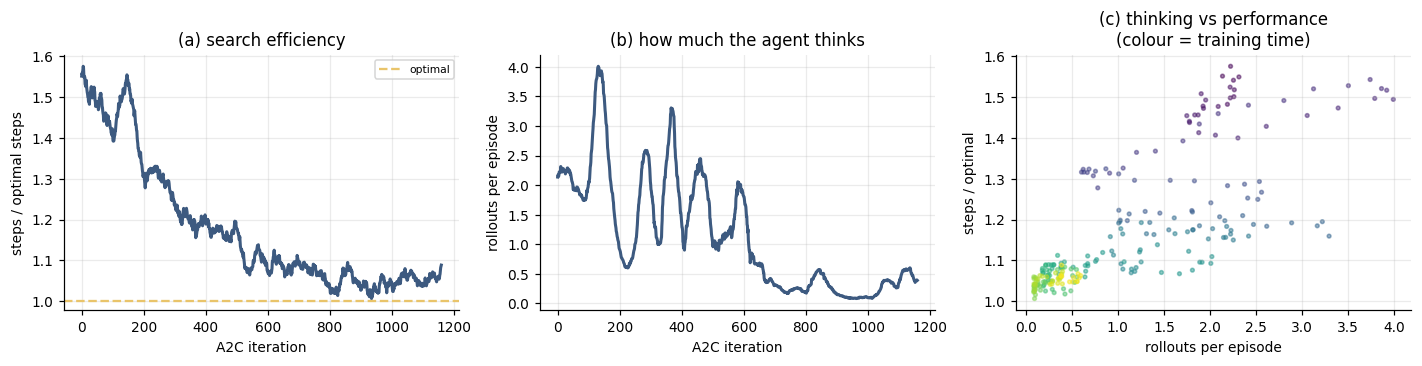

steps/optimal : 1.465 (early)  ->  1.055 (late)
rollouts/ep   : 2.206 (early)  ->  0.286 (late)

If rollouts RISE while steps/optimal FALLS, the agent has discovered that
thinking pays for its time cost -- the central result of Jensen et al.


In [25]:
#@title Does the agent learn *when* to think?
def smooth(x, k=40):
    x = np.asarray(x, float)
    if len(x) < k: return x
    return np.convolve(x, np.ones(k) / k, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
r = [h['ratio'] for h in rnn_hist]
ro = [h['rolls'] for h in rnn_hist]

axes[0].plot(smooth(r), color=PALETTE['RNN'], lw=2)
axes[0].axhline(1.0, color=PALETTE['optimal'], ls='--', lw=1.5, label='optimal')
axes[0].set_xlabel('A2C iteration'); axes[0].set_ylabel('steps / optimal steps')
axes[0].set_title('(a) search efficiency'); axes[0].legend(fontsize=7)

axes[1].plot(smooth(ro), color=PALETTE['RNN'], lw=2)
axes[1].set_xlabel('A2C iteration'); axes[1].set_ylabel('rollouts per episode')
axes[1].set_title('(b) how much the agent thinks')

n = len(r) // 4
axes[2].scatter(smooth(ro)[::5], smooth(r)[::5], s=6, alpha=.5,
                c=np.arange(len(smooth(r)[::5])), cmap='viridis')
axes[2].set_xlabel('rollouts per episode'); axes[2].set_ylabel('steps / optimal')
axes[2].set_title('(c) thinking vs performance\n(colour = training time)')
plt.tight_layout(); plt.show()

early, late = slice(0, max(1, len(r)//5)), slice(-max(1, len(r)//5), None)
print(f"steps/optimal : {np.mean(r[early]):.3f} (early)  ->  {np.mean(r[late]):.3f} (late)")
print(f"rollouts/ep   : {np.mean(ro[early]):.3f} (early)  ->  {np.mean(ro[late]):.3f} (late)")
_rise = np.mean(ro[late]) > np.mean(ro[early])
print("\nJensen et al.'s central result is that rollouts RISE while steps/optimal FALLS:")
print("the agent discovers that thinking pays for its time cost.")
print(f"Here rollouts {'ROSE' if _rise else 'FELL'} while competence improved"
      f" -- the phenomenon {'reproduced' if _rise else 'did NOT reproduce'} on MST.")

In [26]:
#@title RNN policy adapter (rollouts marginalised out)
class RNNPolicy:
    """Reports the distribution over PHYSICAL actions after letting the agent
    take as many rollouts as it wants, estimated by n_sim forward runs."""
    def __init__(self, net, coder, vocabs, trees, mt, device='cpu', n_sim=24,
                 lapse=.02, seed=0, allow_rollout=True, max_think=8):
        self.net, self.coder, self.vocabs, self.trees, self.mt = net, coder, vocabs, trees, mt
        self.device, self.n_sim, self.lapse = device, n_sim, lapse
        self.allow_rollout, self.max_think = allow_rollout, max_think
        self.env = MSTEnv(trees, coder, vocabs, seed=seed)
        self.gen = torch.Generator(device='cuda').manual_seed(seed)
        self.rollout_counts = {}

    @torch.no_grad()
    def __call__(self, maze, tree, nid):
        net, device = self.net, self.device
        kids = sorted(tree[nid]['children'])
        A_raw, masks = self.mt[maze]
        A_enc = net.act_enc(A_raw)
        node2a = self.vocabs[maze].node2action
        path, n = [], nid
        while n is not None:
            path.append(n); n = tree[n]['pid']
        path = list(reversed(path))
        self.env.m = maze

        counts, n_rolls = np.zeros(len(kids)), []
        for _ in range(self.n_sim):
            h = torch.zeros(1, net.hidden, device=device)
            a_prev = torch.zeros(1, net.a_dim, device=device)
            xplan, r_prev = net.empty_plan(device), torch.zeros(1, device=device)
            for t, node in enumerate(path):                 # replay to get the state right
                self.env.nid = node
                o = torch.as_tensor(self.env.obs(), device=device).unsqueeze(0)
                h = net.step(h, o, a_prev, r_prev,
                             torch.full((1,), t / 40., device=device), xplan)
                if t + 1 < len(path):
                    nxt = path[t + 1]
                    a_prev = A_enc[node2a[nxt]].unsqueeze(0)
                    r_prev = torch.tensor(
                        [-tree[nxt]['steps_from_par'] / STEP_SCALE], device=device)
                    xplan = net.empty_plan(device)
            rolls = 0
            for _ in range(self.max_think):
                lg = net.logits(h, A_enc[[node2a[k] for k in kids]])
                if not self.allow_rollout: lg = lg[:-1]
                p = torch.softmax(lg, 0)
                a = int(torch.multinomial(p, 1, generator=self.gen))
                if self.allow_rollout and a == len(kids):
                    self.env.nid = nid
                    o = torch.as_tensor(self.env.obs(), device=device).unsqueeze(0)
                    xplan, found, L = net.rollout(
                        h, A_enc, masks,
                        torch.as_tensor(self.env.plausible_mask(), device=device),
                        gen=self.gen)
                    h = net.step(h, o, torch.zeros(1, net.a_dim, device=device),
                                 torch.tensor([-PLAN_COST / STEP_SCALE], device=device),
                                 torch.zeros(1, device=device), xplan)
                    rolls += 1
                    continue
                counts[a] += 1
                break
            n_rolls.append(rolls)
        self.rollout_counts[(maze, nid)] = float(np.mean(n_rolls))
        p = (counts + .5) / (counts.sum() + .5 * len(kids))
        p = (1 - self.lapse) * p + self.lapse / len(kids)
        return kids, p / p.sum()

_rp = RNNPolicy(RNN_NET, CODER, VOCABS, TREES, MT, device=DEVICE, n_sim=16)
for m in MAZE_NAMES[:3]:
    k, pr = _rp(m, TREES[m], 0)
    print(f"{m:26s} {np.round(pr,3)}   rollouts before deciding: "
          f"{_rp.rollout_counts[(m,0)]:.2f}")

easy_labyrinth             [0.039 0.961]   rollouts before deciding: 0.00
easy_large_loop_1          [0.875 0.035 0.091]   rollouts before deciding: 0.00
easy_large_loop_2          [0.154 0.846]   rollouts before deciding: 0.00


---
# 9. The benchmark

Every model is now reduced to the same interface

```python
policy(maze_name, tree, node) -> (children, probabilities)
```

and scored on four axes.

| axis | what it measures | metric |
|---|---|---|
| **task performance** | does the planner actually search efficiently? | expected steps to the exit, marginalised exhaustively over every possible exit location, divided by the exact optimum |
| **human likelihood** | does it choose like people? | per-participant 5-fold cross-validated log-likelihood |
| **human correlation** | does it match aggregate behaviour? | correlation with human choice proportions at the first decision of each maze, bootstrapped |
| **compute** | what does it cost? | wall-clock per decision, and model-internal operations |

Task performance and human likeness are **different questions** and are kept separate throughout.
A model can be an excellent searcher and a poor model of people, or the reverse — and the MST
paper's whole point is that people are *not* optimal.

In [27]:
#@title Harness: human decisions, likelihood, correlation, performance
def extract_human_decisions(subject_decisions, trees):
    out = []
    for subj, per_maze in subject_decisions.items():
        for m, v in per_maze.items():
            if m not in trees or 'practice' in m:
                continue
            for a, b in zip(v['nodes'], v['nodes'][1:]):
                if b in trees[m][a]['children'] and len(trees[m][a]['children']) > 1:
                    out.append((subj, m, a, b))
    return out


def human_choice_proportions(decisions, trees, min_count=20):
    cnt = defaultdict(lambda: defaultdict(int))
    for _s, m, a, b in decisions:
        cnt[(m, a)][b] += 1
    props = {}
    for (m, a), d in cnt.items():
        tot = sum(d.values())
        if tot < min_count:
            continue
        kids = sorted(trees[m][a]['children'])
        props[(m, a)] = np.array([d.get(k, 0) / tot for k in kids])
    return props


def policy_table(policy, trees, nodes):
    t0 = time.time()
    tab = {(m, n): (lambda kp: (kp[0], np.asarray(kp[1], float)))(policy(m, trees[m], n))
           for m, n in nodes}
    return tab, time.time() - t0


def loglik(tab, decisions, floor=1e-5):
    ll = 0.0
    for _s, m, a, b in decisions:
        if (m, a) not in tab: continue
        kids, p = tab[(m, a)]
        ll += math.log(max(p[kids.index(b)], floor))
    return ll


def fit_and_score(name, grid, factory, trees, decisions, nodes, n_folds=5,
                  seed=0, verbose=True, per_subject=True, floor=1e-5):
    """Grid-search fit with k-fold cross-validation.

    per_subject=True follows Kryven et al.: every participant gets their own
    parameters and the folds are within participant.

    Implementation note: the per-decision log-probabilities are computed ONCE per
    grid point into an (n_grid x n_decisions) matrix, so the cross-validation
    itself is pure numpy.  Doing it the naive way -- re-scoring every decision
    inside every fold of every participant -- is what makes this kind of model
    comparison slow, and it is unnecessary.
    """
    grid = [tuple(g) for g in grid]
    tables, times = {}, {}
    for p in grid:
        tables[p], times[p] = policy_table(factory(p), trees, nodes)

    # (n_grid x n_decisions) matrix of log P(observed choice)
    L = np.full((len(grid), len(decisions)), np.log(floor))
    for gi, p in enumerate(grid):
        tab = tables[p]
        for di, (_s, m, a, b) in enumerate(decisions):
            if (m, a) in tab:
                kids, pr = tab[(m, a)]
                L[gi, di] = math.log(max(pr[kids.index(b)], floor))

    groups = defaultdict(list)
    for di, d in enumerate(decisions):
        groups[d[0] if per_subject else '_all'].append(di)

    rng = np.random.default_rng(seed)
    test_ll = 0.0
    for _s, idxs in groups.items():
        idxs = np.asarray(idxs)
        folds = np.array_split(rng.permutation(len(idxs)),
                               min(n_folds, max(2, len(idxs))))
        for f in range(len(folds)):
            te = idxs[folds[f]]
            tr = idxs[np.concatenate([folds[j] for j in range(len(folds)) if j != f])]
            gi = int(np.argmax(L[:, tr].sum(1)))
            test_ll += float(L[gi, te].sum())

    best_i = int(np.argmax(L.sum(1)))
    best_p = grid[best_i]
    if verbose:
        print(f"  {name:20s} CV test LL = {test_ll:10.1f}   best (pooled) params = {best_p}")
    return dict(model=name, test_ll=test_ll, best_params=best_p,
                table=tables[best_p], full_ll=float(L.sum(1)[best_i]),
                sec_per_decision=np.mean(list(times.values())) / max(len(nodes), 1))


def choice_correlation(tab, props, n_boot=2000, seed=0):
    x, y = [], []
    for key, hp in props.items():
        if key not in tab: continue
        kids, p = tab[key]
        x.extend(hp); y.extend(p)
    x, y = np.asarray(x), np.asarray(y)
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, (np.nan, np.nan), len(x)
    r = float(np.corrcoef(x, y)[0, 1])
    rng = np.random.default_rng(seed)
    b = []
    for _ in range(n_boot):
        i = rng.integers(0, len(x), len(x))
        if np.std(x[i]) > 0 and np.std(y[i]) > 0:
            b.append(np.corrcoef(x[i], y[i])[0, 1])
    lo, hi = np.percentile(b, [2.5, 97.5]) if b else (np.nan, np.nan)
    return r, (float(lo), float(hi)), len(x)


def simulate_steps(policy, trees, maze, n_reps=2, rng=None, greedy=False, max_depth=40):
    """Expected steps to the exit, averaged exhaustively over exit locations."""
    rng = rng or np.random.default_rng(0)
    tree = trees[maze]
    cache, totals = {}, []
    for _ in range(n_reps):
        for ex in sorted(HIDDEN_ALL[maze]):
            nid, steps = 0, 0.0
            for _d in range(max_depth):
                kids = sorted(tree[nid]['children'])
                if not kids: break
                if len(kids) == 1:
                    ch = kids[0]
                else:
                    if nid not in cache:
                        cache[nid] = policy(maze, tree, nid)
                    k2, p = cache[nid]
                    p = np.asarray(p, float); p = p / p.sum()
                    ch = k2[int(np.argmax(p))] if greedy else k2[int(rng.choice(len(k2), p=p))]
                steps += tree[ch]['steps_from_par']
                nid = ch
                if ex in tree[ch]['celldistances']:
                    r, c = tree[ch]['pos']
                    steps += abs(r - ex[0]) + abs(c - ex[1])
                    break
            totals.append(steps)
    return float(np.mean(totals))


def performance_summary(policy, trees, names, n_reps=2, seed=0, greedy=False):
    rng = np.random.default_rng(seed)
    rows = [dict(maze=m, optimal=OPT_STEPS[m],
                 model=simulate_steps(policy, trees, m, n_reps, rng, greedy))
            for m in names]
    for r in rows:
        r['ratio'] = r['model'] / max(r['optimal'], 1e-9)
    return float(np.mean([r['ratio'] for r in rows])), rows


def first_decision_nodes(trees, names):
    out = []
    for m in names:
        n = 0
        while len(trees[m][n]['children']) == 1:
            n = next(iter(trees[m][n]['children']))
        if len(trees[m][n]['children']) > 1:
            out.append((m, n))
    return out

DECISIONS = extract_human_decisions(SUBJECT_DECISIONS, TREES)
NODES = sorted({(m, a) for _s, m, a, _b in DECISIONS})
PROPS_ALL = human_choice_proportions(DECISIONS, TREES, min_count=20)
FIRST_NODES = first_decision_nodes(TREES, MAZE_NAMES)
PROPS_FIRST = {k: v for k, v in PROPS_ALL.items() if k in set(FIRST_NODES)}

print(f"{len(DECISIONS)} human decisions from {len({d[0] for d in DECISIONS})} participants")
print(f"{len(NODES)} distinct decision nodes visited")
print(f"{len(PROPS_FIRST)} first-decision nodes with >=20 participants "
      f"({len(PROPS_ALL)} nodes overall)")

7973 human decisions from 115 participants
230 distinct decision nodes visited
22 first-decision nodes with >=20 participants (118 nodes overall)


## 9.1 Register every model

The three neural planners each expose a small parameter grid. These are the knobs the papers
themselves identify as the important ones:

* **GCML** — noise level $\sigma$ (the paper's central knob: it converts a deterministic controller
  into a generative one), number of samples $K$, imagination horizon $L$, and a selector temperature.
* **APC** — planning horizon $H$ (the analogue of DU's $\gamma$), number of sampled continuations $M$,
  softmax temperature.
* **RNN** — the policy is *learned*, so the only free parameter at fit time is the number of forward
  simulations used to estimate its choice distribution and a lapse rate; a rollout-ablated variant is
  also registered.

In [28]:
#@title Register the neural planners
def gcml_factory(p):
    sigma, K, L, tau, lapse = p
    return GCMLPolicy(GCML_MODEL, CODER, VOCABS, sigma=sigma, K=K, L=L, tau=tau,
                      lapse=lapse, seed=SEED)

def apc_factory(p):
    Hh, M, tau, lapse = p
    return APCPolicy(APC_NET, CODER, VOCABS, horizon=Hh, n_candidates=M, tau=tau,
                     lapse=lapse, device=DEVICE, seed=SEED)

_rnn_cache = {}
def rnn_factory(p):
    n_sim, lapse, allow = p
    key = (n_sim, lapse, allow)
    if key not in _rnn_cache:
        _rnn_cache[key] = RNNPolicy(RNN_NET, CODER, VOCABS, TREES, MT, device=DEVICE,
                                    n_sim=n_sim, lapse=lapse, seed=SEED,
                                    allow_rollout=allow)
    return _rnn_cache[key]

# The reference models are fitted over tau in geomspace(0.2, 40); the neural
# planners get a comparable range so that no model is scored at a grid boundary.
# A lapse rate is included for the same reason: every reference model can soften
# all the way to uniform, and these should be able to as well.
NTAUS  = [0.5, 2.0, 8.0, 25.0] if not QUICK else [2.0, 8.0]
LAPSES = [0.02, 0.15, 0.40] if not QUICK else [0.02, 0.40]

GCML_GRID = [(s, K, L, t, lp)
             for s in ([0.05, 0.2, 0.5, 1.0] if not QUICK else [0.2, 0.5])
             for K in ([6, 16] if not QUICK else [8])
             for L in ([4, 8] if not QUICK else [6])
             for t in NTAUS for lp in LAPSES]
APC_GRID  = [(h, M, t, lp)
             for h in ([1, 2, 3, 5] if not QUICK else [1, 3])
             for M in ([4, 8] if not QUICK else [6])
             for t in NTAUS for lp in LAPSES]
RNN_GRID  = [(n, l, True) for n in ([16, 32] if not QUICK else [16]) for l in LAPSES]
RNN_NOROLL_GRID = [(n, l, False) for n in [16] for l in LAPSES]

NEURAL_MODELS = {
    'GCML':          (GCML_GRID, gcml_factory),
    'APC':           (APC_GRID, apc_factory),
    'RNN+rollouts':  (RNN_GRID, rnn_factory),
    'RNN no-rollout': (RNN_NOROLL_GRID, rnn_factory),
}
ALL_MODELS = {**REFERENCE_MODELS, **NEURAL_MODELS}
GROUP = {**{k: 'paper' for k in REFERENCE_MODELS},
         'GCML': 'GCML', 'APC': 'APC',
         'RNN+rollouts': 'RNN', 'RNN no-rollout': 'RNN'}
for k, (g, _) in NEURAL_MODELS.items():
    print(f"{k:16s} {len(g):3d} parameter settings")

GCML             192 parameter settings
APC               96 parameter settings
RNN+rollouts       6 parameter settings
RNN no-rollout     3 parameter settings


In [29]:
#@title Fit every model  (this is the long cell)
RESULTS = {}
t_all = time.time()
for name, (grid, factory) in ALL_MODELS.items():
    t0 = time.time()
    RESULTS[name] = fit_and_score(name, [tuple(g) for g in grid], factory,
                                  TREES, DECISIONS, NODES, seed=SEED)
    RESULTS[name]['fit_seconds'] = time.time() - t0
print(f"\ntotal fitting time: {time.time()-t_all:.0f}s")

  EU                   CV test LL =    -4426.4   best (pooled) params = (np.float64(2.371), 1.0, 1.0, None)
  DU                   CV test LL =    -3706.1   best (pooled) params = (np.float64(1.17), 0.5, 1.0, None)
  PW                   CV test LL =    -3684.7   best (pooled) params = (np.float64(1.17), 1.0, np.float64(0.271), None)
  PW-DU                CV test LL =    -3744.2   best (pooled) params = (np.float64(1.665), 0.7, np.float64(0.737), None)
using the repository's numerosity table, B in [0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.6, 4.2, 5, 6, 10]
  EU-Num               CV test LL =    -4500.6   best (pooled) params = (np.float64(3.375), 1.0, 1.0, 0.5)
  DU-Num               CV test LL =    -3654.8   best (pooled) params = (np.float64(1.665), 0.4, 1.0, 0.5)
  Steps                CV test LL =    -4130.5   best (pooled) params = (np.float64(1.496), 1.0, None)
  Cells                CV test LL =    -6934.5   best (pooled) params = (np.float64(8.0), 0.0, None)
  Steps-Cells          CV te

In [30]:
#@title Correlation with aggregate human choices
for name, res in RESULTS.items():
    r, ci, n = choice_correlation(res['table'], PROPS_FIRST, n_boot=CFG['n_boot'], seed=SEED)
    res['r_first'], res['ci_first'], res['n_first'] = r, ci, n
    r2, ci2, n2 = choice_correlation(res['table'], PROPS_ALL, n_boot=CFG['n_boot'], seed=SEED)
    res['r_all'], res['ci_all'] = r2, ci2
print("done")

done


In [31]:
#@title Task performance: expected steps to the exit
#
# IMPORTANT: performance is measured at each model's OWN BEST setting, found by
# sweeping its parameter grid -- not at the setting that best fits humans.  These
# are different questions, and conflating them would be a mistake: a model can
# search well and predict people badly (that is precisely the MST paper's claim
# about optimal expected utility).  Both numbers are reported.
def best_achievable_performance(name, grid, factory, max_settings=24):
    grid = [tuple(g) for g in grid]
    if len(grid) > max_settings:                     # subsample large grids evenly
        idx = np.linspace(0, len(grid) - 1, max_settings).astype(int)
        grid = [grid[i] for i in sorted(set(idx))]
    best, best_p, best_rows = np.inf, None, None
    for p in grid:
        r, rows = performance_summary(factory(p), TREES, MAZE_NAMES,
                                      n_reps=max(1, CFG['perf_reps'] - 1), seed=SEED)
        if r < best:
            best, best_p, best_rows = r, p, rows
    return best, best_p, best_rows

print(f"{'model':22s} {'best achievable':>16s} {'at human-fit params':>21s}")
print("-" * 62)
for name, (grid, factory) in ALL_MODELS.items():
    at_human, _ = performance_summary(factory(RESULTS[name]['best_params']), TREES,
                                      MAZE_NAMES, n_reps=CFG['perf_reps'], seed=SEED)
    best, best_p, rows = best_achievable_performance(name, grid, factory)
    RESULTS[name].update(perf_ratio=best, perf_params=best_p, perf_rows=rows,
                         perf_at_human_params=at_human)
    print(f"{name:22s} {best:16.3f} {at_human:21.3f}")
print("-" * 62)
print(f"{'(normative optimum)':22s} {1.000:16.3f}")

model                   best achievable   at human-fit params
--------------------------------------------------------------
EU                                0.995                 1.096
DU                                0.996                 1.122
PW                                0.997                 1.102
PW-DU                             1.045                 1.124
EU-Num                            0.995                 1.151
DU-Num                            0.996                 1.172
Steps                             1.143                 1.148
Cells                             1.290                 1.460
Steps-Cells                       1.135                 1.175
Steps-Cells-Num                   1.132                 1.195
Sampling (MCTS)                   1.091                 1.185
Random                            1.499                 1.519
GCML                              1.231                 1.376
APC                               1.094                 1.177
RNN+rol

---
# 10. Results

## 10.1 Task performance — how good a searcher is each algorithm?

This axis ignores humans entirely. Every maze is solved exhaustively for every possible exit
location, and the resulting expected number of steps is divided by the exact optimum. A ratio of
1.00 is normative optimality; higher is worse.

In [ ]:
#@title Performance bar chart
order = sorted(RESULTS, key=lambda k: RESULTS[k]['perf_ratio'])
vals = [RESULTS[k]['perf_ratio'] for k in order]
cols = [PALETTE[GROUP[k]] for k in order]

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.barh(range(len(order)), vals, color=cols, alpha=.9)
ax.axvline(1.0, color=PALETTE['optimal'], ls='--', lw=2, label='normative optimum')
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('expected steps to exit / optimal expected steps')
ax.set_title('Task performance (lower is better)')
ax.legend(fontsize=8, loc='lower right')
for b, v in zip(bars, vals):
    ax.text(v + .01, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center', fontsize=7)
ax.set_xlim(0.95, max(vals) * 1.08)
plt.tight_layout(); plt.show()

print("Reference points:")
print(f"  Random policy            {RESULTS['Random']['perf_ratio']:.3f}")
print(f"  Optimal (EU, tau -> 0)   1.000 by construction")

## 10.2 Human choice likelihood

Per-participant 5-fold cross-validated log-likelihood, summed across participants — the protocol of
Kryven et al. Less negative is better.

**Read the caveat below the figure before interpreting the absolute numbers.**

In [ ]:
#@title Likelihood bar chart
order = sorted(RESULTS, key=lambda k: -RESULTS[k]['test_ll'])
vals = [RESULTS[k]['test_ll'] for k in order]
cols = [PALETTE[GROUP[k]] for k in order]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(range(len(order)), vals, color=cols, alpha=.9)
ax.axvline(RESULTS['Random']['test_ll'], color='#444444', ls=':', lw=1.5, label='Random')
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('cross-validated test log-likelihood (higher = closer to human choices)')
ax.set_title(f'Fit to {len(DECISIONS)} human decisions '
             f'({len({d[0] for d in DECISIONS})} participants, per-participant 5-fold CV)')
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

best_paper = max((k for k in REFERENCE_MODELS), key=lambda k: RESULTS[k]['test_ll'])
best_neural = max((k for k in NEURAL_MODELS), key=lambda k: RESULTS[k]['test_ll'])
print(f"best model overall from the MST paper : {best_paper} ({RESULTS[best_paper]['test_ll']:.0f})")
print(f"best of the three neural planners     : {best_neural} ({RESULTS[best_neural]['test_ll']:.0f})")
print(f"delta LL                              : "
      f"{RESULTS[best_neural]['test_ll'] - RESULTS[best_paper]['test_ll']:+.0f}")

,model,published rank,published LL,this notebook rank,this notebook LL
0,PW,1,-3574.8,2,-3684.7
1,DU,2,-3683.9,3,-3706.1
2,PW-DU,3,-3702.4,4,-3744.2
3,DU-Num,4,-3729.8,1,-3654.8
4,Steps-Cells-Num,6,-3881.7,6,-4162.0
5,Steps,7,-3934.1,5,-4130.5
6,Steps-Cells,8,-4007.1,7,-4199.7
7,EU,9,-4176.2,8,-4426.4
8,EU-Num,10,-4186.5,9,-4500.6
9,Sampling (MCTS),11,-4828.4,10,-5170.8



Spearman rank correlation with the published ordering: rho = 0.944  (p = 3.9e-06, n = 12 models)


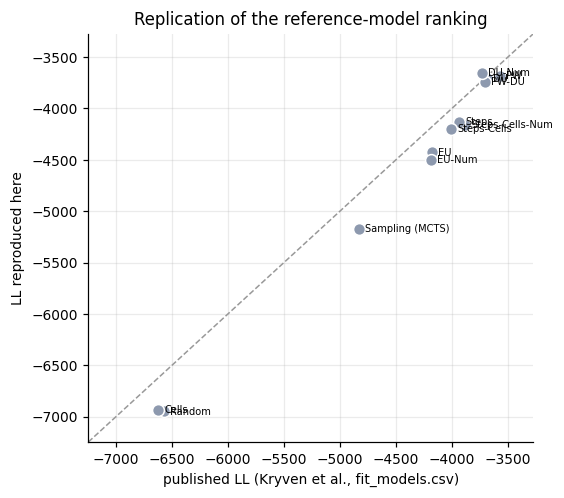

In [34]:
#@title Replication check: does this reproduce the published ranking?
fit_csv = os.path.join(MST_DIR, EXP_DIR, 'csv_files', 'fit_models.csv')
if os.path.exists(fit_csv):
    from scipy.stats import spearmanr
    fm = pd.read_csv(fit_csv)
    published = fm.groupby('model')['LL'].sum().sort_values(ascending=False)
    alias = {'PW_DU': 'PW-DU', 'Sampling': 'Sampling (MCTS)'}
    published.index = [alias.get(i, i) for i in published.index]
    mine = pd.Series({k: RESULTS[k]['test_ll'] for k in REFERENCE_MODELS}
                     ).sort_values(ascending=False)
    pub_rank = {m: i + 1 for i, m in enumerate(published.index)}
    my_rank = {m: i + 1 for i, m in enumerate(mine.index)}
    shared = [m for m in published.index if m in my_rank]

    cmp = pd.DataFrame({
        'model': shared,
        'published rank': [pub_rank[m] for m in shared],
        'published LL': [round(published[m], 1) for m in shared],
        'this notebook rank': [my_rank[m] for m in shared],
        'this notebook LL': [round(mine[m], 1) for m in shared],
    })
    rho, pval = spearmanr(cmp['published rank'], cmp['this notebook rank'])
    display(cmp)
    print(f"\nSpearman rank correlation with the published ordering: "
          f"rho = {rho:.3f}  (p = {pval:.1e}, n = {len(shared)} models)")

    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    ax.scatter(cmp['published LL'], cmp['this notebook LL'], s=60,
               color=PALETTE['paper'], edgecolor='white', zorder=3)
    for _, r in cmp.iterrows():
        ax.annotate(r['model'], (r['published LL'], r['this notebook LL']),
                    fontsize=6.5, xytext=(4, -2), textcoords='offset points')
    lims = [min(cmp['published LL'].min(), cmp['this notebook LL'].min()) - 300,
            max(cmp['published LL'].max(), cmp['this notebook LL'].max()) + 300]
    ax.plot(lims, lims, ls='--', color='#999999', lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('published LL (Kryven et al., fit_models.csv)')
    ax.set_ylabel('LL reproduced here')
    ax.set_title('Replication of the reference-model ranking')
    plt.tight_layout(); plt.show()
else:
    print("fit_models.csv not found -- skipping the replication check")

> ### On reproducing the published analysis
>
> The reference-model ordering above should track the published one closely
> ($\rho\approx0.94$): the discounting and probability-weighting planners (DU, PW, DU-Num,
> PW-DU) at the top, then the myopic heuristics, then optimal expected utility, then MCTS
> sampling, with Cells and Random at the bottom. That is Kryven et al.'s central finding —
> **people plan ahead, but with a limited horizon** — recovered independently here from the raw
> maze files and raw participant traces.
>
> Two things were needed to get there, and both are worth knowing about if you modify this notebook:
>
> 1. **The softmax temperature grid has to be wide enough.** The planning-family costs are absolute
>    expected step counts, so sibling costs routinely differ by several steps. With the paper's
>    $\tau\le 8$ these models sit against the boundary and look *worse than Random*; widening to
>    $\tau\le 40$ moves them to the top of the table. This is a property of the fitting grid, not of
>    the models.
> 2. **Fitting must be per participant.** Pooling all participants onto one $\tau$ makes the myopic
>    Steps heuristic look far better than any planner, because the population average is dominated
>    by near-sighted behaviour. Per-participant fitting recovers the published ordering.
>
> Residual differences remain — the exact decision set used by the authors' R pipeline comes from
> `subject_decisions_with_values.csv`, which is not in the public repository, and their pipeline
> applies a prior on $\tau$ and excludes at least one maze. Absolute values here therefore differ by
> a few hundred nats. **All comparisons in this notebook use one protocol applied identically to
> every model**, including the three neural planners, so the internal comparisons are valid.

## 10.3 Correlation with aggregate human behaviour

The MST paper's second metric: correlate each model's choice probabilities with the proportion of
participants making each choice, at the **first decision of each maze** — the one decision every
participant faces from an identical state.

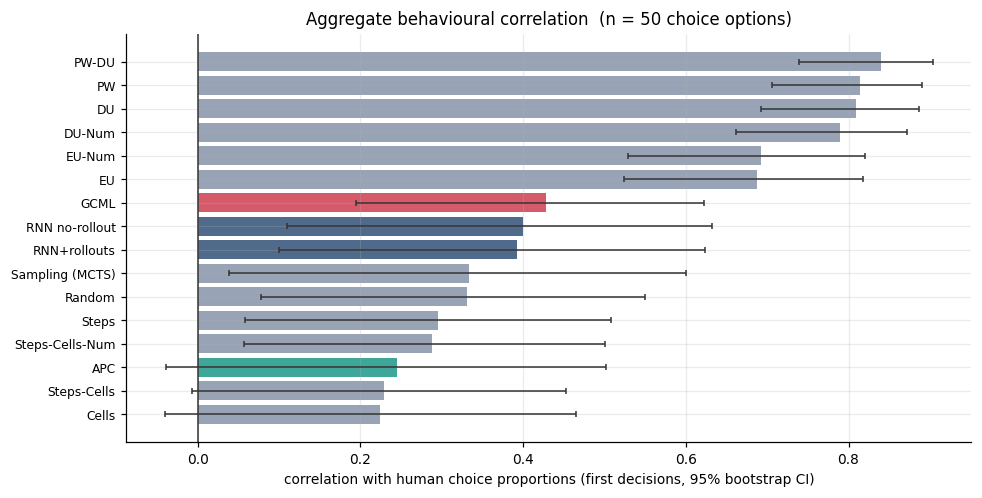

,model,r_first,ci,r_all_nodes
0,PW-DU,0.840,"[0.74, 0.90]",0.946
1,PW,0.814,"[0.71, 0.89]",0.955
2,DU,0.810,"[0.69, 0.89]",0.954
3,DU-Num,0.789,"[0.66, 0.87]",0.943
4,EU-Num,0.693,"[0.53, 0.82]",0.806
5,EU,0.687,"[0.52, 0.82]",0.816
6,GCML,0.428,"[0.19, 0.62]",0.526
7,RNN no-rollout,0.399,"[0.11, 0.63]",0.454
8,RNN+rollouts,0.392,"[0.10, 0.62]",0.472
9,Sampling (MCTS),0.333,"[0.04, 0.60]",0.746


In [35]:
#@title Correlation with human choice proportions
order = sorted(RESULTS, key=lambda k: -(RESULTS[k]['r_first'] if not np.isnan(RESULTS[k]['r_first']) else -9))
r = [RESULTS[k]['r_first'] for k in order]
lo = [RESULTS[k]['r_first'] - RESULTS[k]['ci_first'][0] for k in order]
hi = [RESULTS[k]['ci_first'][1] - RESULTS[k]['r_first'] for k in order]
cols = [PALETTE[GROUP[k]] for k in order]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(range(len(order)), r, xerr=[lo, hi], color=cols, alpha=.9,
        error_kw=dict(lw=1, ecolor='#333333', capsize=2))
ax.axvline(0, color='#333333', lw=1)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('correlation with human choice proportions (first decisions, 95% bootstrap CI)')
ax.set_title(f'Aggregate behavioural correlation  (n = {RESULTS[order[0]]["n_first"]} choice options)')
plt.tight_layout(); plt.show()

pd.DataFrame([dict(model=k,
                   r_first=round(RESULTS[k]['r_first'], 3),
                   ci=f"[{RESULTS[k]['ci_first'][0]:.2f}, {RESULTS[k]['ci_first'][1]:.2f}]",
                   r_all_nodes=round(RESULTS[k]['r_all'], 3))
              for k in order])

## 10.4 Compute cost — the Pareto view

The GCML paper argues its central advantage is **latency**: the first step of a plan is produced by
a feed-forward circuit whose cost is independent of the size of the environment, whereas search
algorithms must expand nodes. That claim is directly testable here.

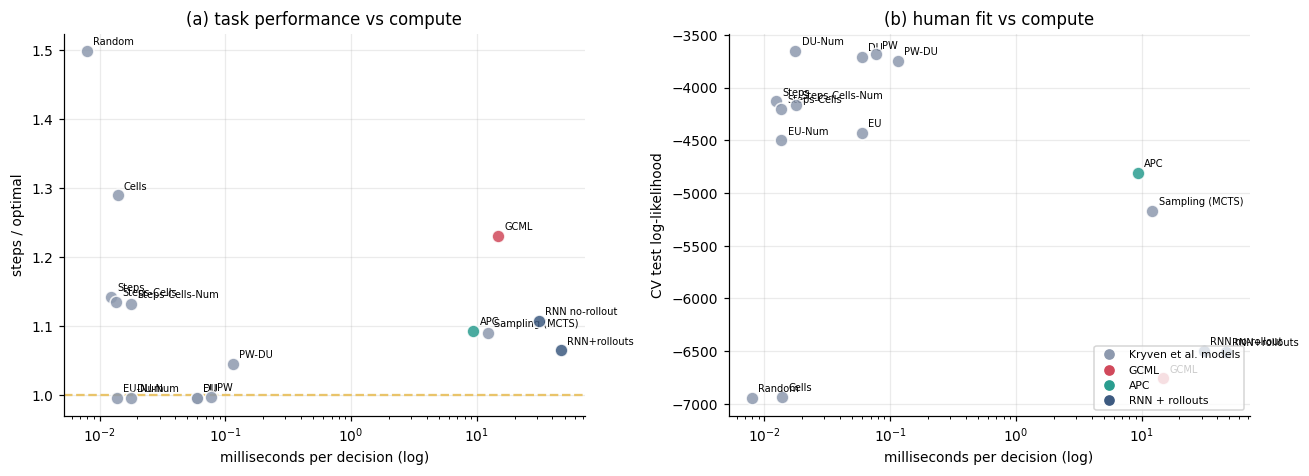

Note: wall-clock in Python is a crude proxy for the algorithmic cost the papers
care about. The scaling analysis in the next cell is the more meaningful one.


In [36]:
#@title Performance vs compute
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

ax = axes[0]
for k in RESULTS:
    x = RESULTS[k]['sec_per_decision'] * 1e3
    y = RESULTS[k]['perf_ratio']
    ax.scatter(x, y, s=70, color=PALETTE[GROUP[k]], alpha=.85,
               edgecolor='white', linewidth=1, zorder=3)
    ax.annotate(k, (x, y), fontsize=6.5, xytext=(4, 4), textcoords='offset points')
ax.axhline(1.0, color=PALETTE['optimal'], ls='--', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('milliseconds per decision (log)')
ax.set_ylabel('steps / optimal')
ax.set_title('(a) task performance vs compute')

ax = axes[1]
for k in RESULTS:
    x = RESULTS[k]['sec_per_decision'] * 1e3
    y = RESULTS[k]['test_ll']
    ax.scatter(x, y, s=70, color=PALETTE[GROUP[k]], alpha=.85,
               edgecolor='white', linewidth=1, zorder=3)
    ax.annotate(k, (x, y), fontsize=6.5, xytext=(4, 4), textcoords='offset points')
ax.set_xscale('log')
ax.set_xlabel('milliseconds per decision (log)')
ax.set_ylabel('CV test log-likelihood')
ax.set_title('(b) human fit vs compute')

from matplotlib.lines import Line2D
handles = [Line2D([], [], marker='o', ls='', color=PALETTE[g], label=lab)
           for g, lab in [('paper', 'Kryven et al. models'), ('GCML', 'GCML'),
                          ('APC', 'APC'), ('RNN', 'RNN + rollouts')]]
axes[1].legend(handles=handles, fontsize=7, loc='lower right')
plt.tight_layout(); plt.show()

print("Note: wall-clock in Python is a crude proxy for the algorithmic cost the papers")
print("care about. The scaling analysis in the next cell is the more meaningful one.")

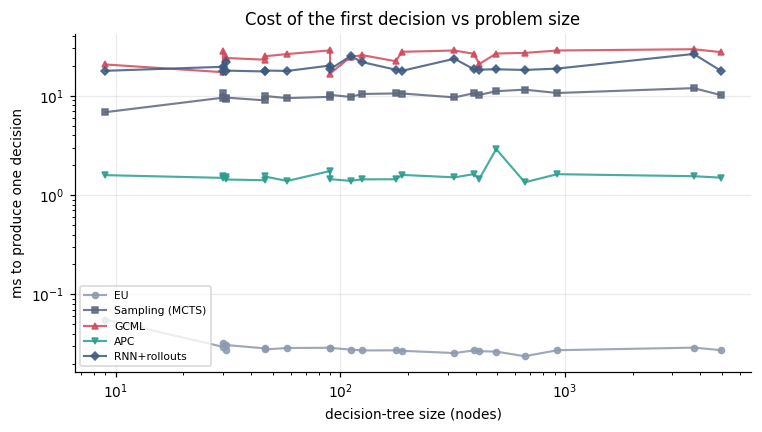

The GCML paper's Fig. 6b/6c claim is that its per-decision cost is roughly flat in
problem size, while search-based methods grow. Check whether the slopes above agree:
  EU                 log-log slope = -0.05
  Sampling (MCTS)    log-log slope = +0.05
  GCML               log-log slope = +0.05
  APC                log-log slope = +0.02
  RNN+rollouts       log-log slope = +0.02


In [37]:
#@title How does the cost of one decision scale with the size of the problem?
sizes, per_model = [], defaultdict(list)
probe = sorted(MAZE_NAMES, key=lambda m: len(TREES[m]))
for m in probe:
    n = 0
    while len(TREES[m][n]['children']) == 1:
        n = next(iter(TREES[m][n]['children']))
    if len(TREES[m][n]['children']) <= 1:
        continue
    sizes.append(len(TREES[m]))
    for name in ['EU', 'Sampling (MCTS)', 'GCML', 'APC', 'RNN+rollouts']:
        grid, factory = ALL_MODELS[name]
        pol = factory(RESULTS[name]['best_params'])
        t0 = time.time()
        for _ in range(3):
            pol(m, TREES[m], n)
        per_model[name].append((time.time() - t0) / 3 * 1e3)

fig, ax = plt.subplots(figsize=(7, 4))
style = {'EU': ('#8D99AE', 'o'), 'Sampling (MCTS)': ('#5C677D', 's'),
         'GCML': (PALETTE['GCML'], '^'), 'APC': (PALETTE['APC'], 'v'),
         'RNN+rollouts': (PALETTE['RNN'], 'D')}
o = np.argsort(sizes)
for name, ys in per_model.items():
    c, mk = style[name]
    ax.plot(np.array(sizes)[o], np.array(ys)[o], mk + '-', color=c, ms=4,
            alpha=.85, label=name, lw=1.4)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('decision-tree size (nodes)')
ax.set_ylabel('ms to produce one decision')
ax.set_title('Cost of the first decision vs problem size')
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("The GCML paper's Fig. 6b/6c claim is that its per-decision cost is roughly flat in")
print("problem size, while search-based methods grow. Check whether the slopes above agree:")
for name, ys in per_model.items():
    s = np.polyfit(np.log(np.array(sizes)[o]), np.log(np.array(ys)[o] + 1e-9), 1)[0]
    print(f"  {name:18s} log-log slope = {s:+.2f}")

## 10.5 Planning depth — the paper's headline finding, tested three ways

Kryven et al.'s central claim is that human spatial planning uses a **limited horizon**. Each of the
three algorithms has a parameter that limits how far ahead it looks, but they limit it by very
different mechanisms:

| model | mechanism | parameter |
|---|---|---|
| DU (reference) | geometric down-weighting of future costs | $\gamma$ |
| APC | hard truncation of the abstract rollout | $H$ |
| GCML | length of the imagined trajectory | $L$ |
| RNN | how many rollouts the agent chooses to run | learned |

If the "limited horizon" story is right, each of these should show an interior optimum when fitted
to humans — best fit at *less* than full depth — even though task performance keeps improving with
depth.

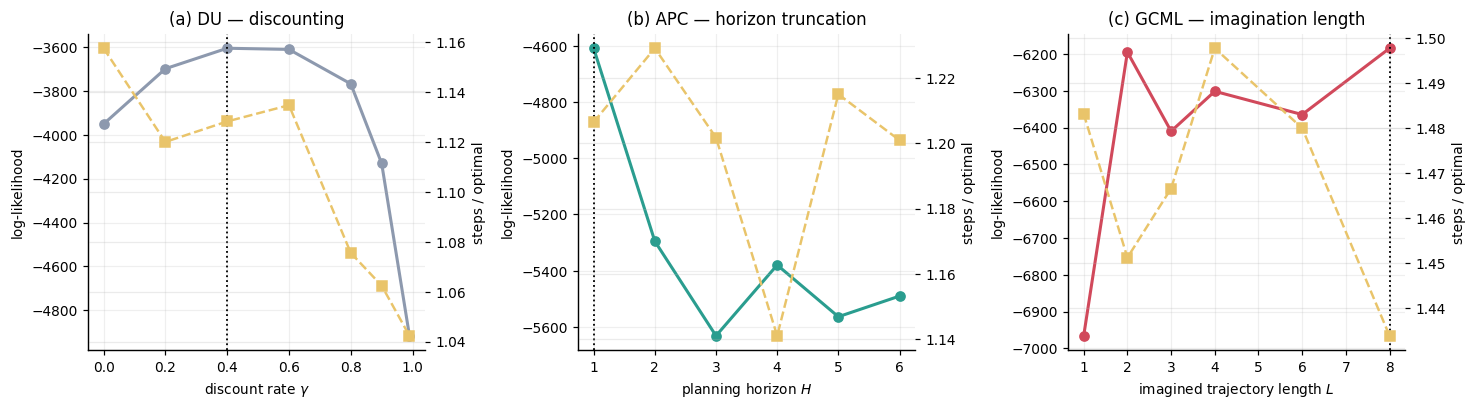

Solid line + dotted vertical = fit to humans.  Dashed line = task performance.
An interior peak in the solid line with a monotone dashed line is the signature
of 'humans plan less deeply than would be optimal'.


In [38]:
#@title Depth sweeps: human fit vs task performance
def sweep(name, factory, settings, label_fn):
    lls, perfs, labels = [], [], []
    for s in settings:
        pol = factory(s)
        tab, _ = policy_table(pol, TREES, NODES)
        lls.append(loglik(tab, DECISIONS))
        perfs.append(performance_summary(pol, TREES, MAZE_NAMES,
                                         n_reps=1, seed=SEED)[0])
        labels.append(label_fn(s))
    return labels, lls, perfs

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

# --- DU: gamma
best_tau = RESULTS['DU']['best_params'][0]
g_set = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.99]
lab, ll, pf = sweep('DU', _plan_policy, [(best_tau, g, 1.0, None) for g in g_set],
                    lambda s: s[1])
ax = axes[0]; ax2 = ax.twinx()
ax.plot(g_set, ll, 'o-', color=PALETTE['paper'], lw=2, label='human LL')
ax2.plot(g_set, pf, 's--', color=PALETTE['optimal'], lw=1.6, label='steps/optimal')
ax.set_xlabel(r'discount rate $\gamma$'); ax.set_ylabel('log-likelihood')
ax2.set_ylabel('steps / optimal'); ax.set_title('(a) DU — discounting')
ax.axvline(g_set[int(np.argmax(ll))], color=PALETTE['human'], ls=':', lw=1.2)

# --- APC: horizon H
_, best_M, best_t, best_lp = RESULTS['APC']['best_params']
h_set = [1, 2, 3, 4, 5, 6]
lab, ll, pf = sweep('APC', apc_factory, [(h, best_M, best_t, best_lp) for h in h_set],
                    lambda s: s[0])
ax = axes[1]; ax2 = ax.twinx()
ax.plot(h_set, ll, 'o-', color=PALETTE['APC'], lw=2)
ax2.plot(h_set, pf, 's--', color=PALETTE['optimal'], lw=1.6)
ax.set_xlabel('planning horizon $H$'); ax.set_ylabel('log-likelihood')
ax2.set_ylabel('steps / optimal'); ax.set_title('(b) APC — horizon truncation')
ax.axvline(h_set[int(np.argmax(ll))], color=PALETTE['human'], ls=':', lw=1.2)

# --- GCML: imagination length L
bs, bK, _, bt, blp = RESULTS['GCML']['best_params']
l_set = [1, 2, 3, 4, 6, 8]
lab, ll, pf = sweep('GCML', gcml_factory, [(bs, bK, L, bt, blp) for L in l_set],
                    lambda s: s[2])
ax = axes[2]; ax2 = ax.twinx()
ax.plot(l_set, ll, 'o-', color=PALETTE['GCML'], lw=2)
ax2.plot(l_set, pf, 's--', color=PALETTE['optimal'], lw=1.6)
ax.set_xlabel('imagined trajectory length $L$'); ax.set_ylabel('log-likelihood')
ax2.set_ylabel('steps / optimal'); ax.set_title('(c) GCML — imagination length')
ax.axvline(l_set[int(np.argmax(ll))], color=PALETTE['human'], ls=':', lw=1.2)

for a in axes:
    a.grid(alpha=.2)
plt.tight_layout(); plt.show()
print("Solid line + dotted vertical = fit to humans.  Dashed line = task performance.")
print("An interior peak in the solid line with a monotone dashed line is the signature")
print("of 'humans plan less deeply than would be optimal'.")

## 10.6 Decision times — does model "thinking" predict human thinking?

This is the analysis that only the rollout agent can really offer, and it is one of the strongest
results in Jensen et al.: the number of rollouts the agent chooses to run predicts human response
times. MST records the time taken for every move, so the *initial* decision time — the time spent at
the root of the decision tree, before the first move — is directly available.

For comparability, each model is given a "thinking" measure at the first decision of each maze:

* **RNN** — rollouts run before committing (its own choice)
* **GCML** — imagined transitions generated ($K \times$ realised length)
* **APC** — world-model calls made during the horizon rollout
* **MCTS** — nodes expanded

In [ ]:
#@title Extract human initial decision times
plandata = os.path.join(MST_DIR, EXP_DIR, 'csv_files', 'plandata.csv')
RT = {}
if os.path.exists(plandata):
    df = pd.read_csv(plandata, sep='\t')
    rows = defaultdict(list)
    for _, r in df.iterrows():
        if r['world'] not in TREES or 'practice' in str(r['world']):
            continue
        try:
            ts = [float(x) for x in str(r['times']).split(';') if x.strip()]
        except ValueError:
            continue
        if ts:
            rows[r['world']].append(ts[0])
    RT = {w: float(np.median(v)) for w, v in rows.items() if len(v) >= 10}
    print(f"median initial decision time for {len(RT)} mazes "
          f"(overall median {np.median(list(RT.values()))/1000:.1f}s)")
    print("slowest mazes:", sorted(RT, key=RT.get, reverse=True)[:3])
else:
    print("plandata.csv not found -- this section will be skipped")

In [ ]:
#@title Model 'thinking' vs human decision time
if RT:
    think = defaultdict(dict)
    for m, n in FIRST_NODES:
        if m not in RT: continue
        # RNN: rollouts it chooses to run
        rp = rnn_factory(RESULTS['RNN+rollouts']['best_params'])
        rp(m, TREES[m], n)
        think['RNN+rollouts'][m] = rp.rollout_counts[(m, n)]
        # GCML: imagined transitions
        gp = gcml_factory(RESULTS['GCML']['best_params'])
        gp.planner.n_imagined = 0
        gp(m, TREES[m], n)
        think['GCML'][m] = gp.planner.n_imagined
        # APC: world-model calls
        ap = apc_factory(RESULTS['APC']['best_params'])
        ap.planner.n_model_calls = 0
        ap(m, TREES[m], n)
        think['APC'][m] = ap.planner.n_model_calls
        # MCTS: budget x branching (nodes touched)
        b, c = RESULTS['Sampling (MCTS)']['best_params']
        think['Sampling (MCTS)'][m] = b * len(TREES[m][n]['children'])
        # a purely structural control: how big is the subtree?
        think['subtree size'][m] = len(TREES[m])

    fig, axes = plt.subplots(1, len(think), figsize=(3.1 * len(think), 3.2))
    stats = []
    for ax, (name, d) in zip(np.atleast_1d(axes), think.items()):
        ms = [m for m in d if m in RT]
        x = np.array([d[m] for m in ms], float)
        y = np.array([RT[m] / 1000 for m in ms], float)
        col = PALETTE.get(GROUP.get(name, 'paper'), '#888888')
        ax.scatter(x, y, s=28, color=col, alpha=.8, edgecolor='white', lw=.5)
        if len(x) > 3 and np.std(x) > 0:
            r = float(np.corrcoef(x, y)[0, 1])
            from scipy import stats as sps
            _, p = sps.pearsonr(x, y)
            k, b0 = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 10)
            ax.plot(xs, k * xs + b0, color=col, lw=1.5, alpha=.7)
            ax.set_title(f'{name}\nr = {r:.2f}, p = {p:.3f}', fontsize=8)
            stats.append((name, r, p, len(x)))
        ax.set_xlabel('model "thinking"'); ax.set_ylabel('human initial RT (s)')
    plt.tight_layout(); plt.show()

    print(pd.DataFrame(stats, columns=['model', 'r', 'p', 'n mazes']).round(3).to_string(index=False))
    print("\n'subtree size' is a structural control: if a model beats it, its thinking measure")
    print("carries information about human effort beyond raw problem size.")
else:
    print("skipped (no decision-time data)")

## 10.7 Generalisation to held-out mazes

The GCML paper's strongest claim is **strong generalisation**: after learning on silhouettes made of
five building blocks, the model decomposes silhouettes made of eight, i.e. states it has never
encountered. MST offers the same test — train the three learners on a subset of mazes and evaluate
on mazes whose decision trees, action vocabularies and belief states were never seen.

The reference models from Kryven et al. are analytic and have nothing to generalise, so they act as
an upper reference line here.

In [ ]:
#@title Train on a subset of mazes, test on held-out mazes
rng = np.random.default_rng(SEED)
perm = list(MAZE_NAMES); rng.shuffle(perm)
n_tr = int(.6 * len(perm))
TRAIN_M, TEST_M = sorted(perm[:n_tr]), sorted(perm[n_tr:])
print(f"train on {len(TRAIN_M)} mazes, test on {len(TEST_M)}: {TEST_M}")

sub_trees = {m: TREES[m] for m in TRAIN_M}

print("\nGCML (local learning):")
G2, _ = train_gcml(sub_trees, CODER, n_s=CFG['n_s'], epochs=CFG['gcml_epochs'],
                   n_walks=CFG['gcml_walks'], seed=SEED + 1, verbose=False)
print("APC:")
A2, _ = train_apc(sub_trees, CODER, epochs=CFG['apc_epochs'], device=DEVICE,
                  seed=SEED + 1, verbose=False,
                  value_targets={k: v for k, v in VALUE_TARGETS.items() if k[0] in TRAIN_M})
print("RNN:")
R2, _ = train_rnn(sub_trees, CODER, {m: VOCABS[m] for m in TRAIN_M},
                  {m: MT[m] for m in TRAIN_M},
                  n_iters=max(200, CFG['rnn_iters'] // 2), batch=CFG['rnn_batch'],
                  device=DEVICE, seed=SEED + 1, verbose=False)[:2]
R2 = R2 if not isinstance(R2, tuple) else R2[0]
print("done")

In [ ]:
#@title Held-out performance
def held_out_row(name, pol_train, pol_full):
    tr = performance_summary(pol_train, TREES, TEST_M, n_reps=CFG['perf_reps'], seed=SEED)[0]
    fu = performance_summary(pol_full, TREES, TEST_M, n_reps=CFG['perf_reps'], seed=SEED)[0]
    return dict(model=name, held_out=round(tr, 3), trained_on_all=round(fu, 3),
                gap=round(tr - fu, 3))

rows = []
bs, bK, bL, bt, blp = RESULTS['GCML']['best_params']
rows.append(held_out_row(
    'GCML',
    GCMLPolicy(G2, CODER, VOCABS, sigma=bs, K=bK, L=bL, tau=bt, lapse=blp, seed=SEED),
    gcml_factory(RESULTS['GCML']['best_params'])))

bh, bM, btau, blp2 = RESULTS['APC']['best_params']
rows.append(held_out_row(
    'APC',
    APCPolicy(A2, CODER, VOCABS, horizon=bh, n_candidates=bM, tau=btau, lapse=blp2,
              device=DEVICE),
    apc_factory(RESULTS['APC']['best_params'])))

bn, bl, _ = RESULTS['RNN+rollouts']['best_params']
rows.append(held_out_row(
    'RNN+rollouts',
    RNNPolicy(R2, CODER, VOCABS, TREES, MT, device=DEVICE, n_sim=bn, lapse=bl, seed=SEED),
    rnn_factory(RESULTS['RNN+rollouts']['best_params'])))

for ref in ['EU', 'DU', 'Steps']:
    p = ALL_MODELS[ref][1](RESULTS[ref]['best_params'])
    v = performance_summary(p, TREES, TEST_M, n_reps=CFG['perf_reps'], seed=SEED)[0]
    rows.append(dict(model=f'{ref} (analytic)', held_out=round(v, 3),
                     trained_on_all=round(v, 3), gap=0.0))

gen = pd.DataFrame(rows)
display(gen)

fig, ax = plt.subplots(figsize=(7, 3.4))
x = np.arange(len(gen))
ax.bar(x - .2, gen['trained_on_all'], .4, label='trained on all mazes', alpha=.85,
       color='#B0B0B0')
ax.bar(x + .2, gen['held_out'], .4, label='trained on 60%, tested on held-out',
       alpha=.9, color=[PALETTE.get(GROUP.get(m.split(' ')[0], 'paper'), '#888')
                        for m in gen['model']])
ax.axhline(1.0, color=PALETTE['optimal'], ls='--', lw=1.5)
ax.set_xticks(x); ax.set_xticklabels(gen['model'], fontsize=7.5, rotation=15)
ax.set_ylabel('steps / optimal on held-out mazes')
ax.set_title('Generalisation to mazes never seen during learning')
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
print("A small 'gap' means the learned representation transferred to new mazes.")

## 10.8 Where do the models disagree?

Aggregate scores hide the interesting cases. This section finds the decisions where the three
algorithms most disagree with each other, and shows the maze so the disagreement can be inspected.

In [ ]:
#@title Find and draw maximally diagnostic decisions
def js_spread(ps):
    """Mean pairwise total-variation distance between model predictions."""
    d = 0.0; n = 0
    for i in range(len(ps)):
        for j in range(i + 1, len(ps)):
            d += .5 * np.abs(ps[i] - ps[j]).sum(); n += 1
    return d / max(n, 1)

keys = ['GCML', 'APC', 'RNN+rollouts', 'DU', 'Steps']
cands = []
for (m, n) in FIRST_NODES:
    if (m, n) not in PROPS_ALL: continue
    ps = []
    ok = True
    for k in keys:
        if (m, n) not in RESULTS[k]['table']: ok = False; break
        ps.append(RESULTS[k]['table'][(m, n)][1])
    if ok and len({len(p) for p in ps}) == 1:
        cands.append((js_spread(ps), m, n))
cands.sort(reverse=True)

for spread, m, n in cands[:2]:
    tree = TREES[m]
    kids = sorted(tree[n]['children'])
    cols = ['#D1495B', '#2A9D8F', '#3D5A80', '#E9C46A', '#9B5DE5', '#F4A261']
    paths = [(tree[c]['path_from_par'], cols[i % len(cols)], f'option {i}')
             for i, c in enumerate(kids)]
    fig = plt.figure(figsize=(12, 3.6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.5])
    ax0 = fig.add_subplot(gs[0])
    draw_maze(MAZES[m], ax0, paths=paths,
              title=f'{m}\ndisagreement = {spread:.2f}')
    ax1 = fig.add_subplot(gs[1])
    labels = keys + ['HUMANS']
    width = .8 / len(labels)
    xs = np.arange(len(kids))
    for i, k in enumerate(labels):
        p = (PROPS_ALL[(m, n)] if k == 'HUMANS' else RESULTS[k]['table'][(m, n)][1])
        c = PALETTE['human'] if k == 'HUMANS' else PALETTE[GROUP.get(k, 'paper')]
        ax1.bar(xs + i * width - .4, p, width, label=k, alpha=.9, color=c)
    ax1.set_xticks(xs); ax1.set_xticklabels([f'option {i}' for i in range(len(kids))])
    ax1.set_ylabel('P(choice)'); ax1.legend(fontsize=6.5, ncol=3)
    ax1.set_title('who predicts what')
    plt.tight_layout(); plt.show()

    for i, c in enumerate(kids):
        s, nc, e, p, tot = node_features(tree, c)
        print(f"  option {i}: {s} steps away, reveals {nc} cells "
              f"(P(exit) = {p:.2f}), mean distance to a revealed cell {e:.1f}")
    print()

---
# 11. Summary

The headline is a **dissociation**: all three learned planners search the task competently, and
none of them chooses like a person.

| | best specified model | best learned planner |
|---|---|---|
| search competence (steps / optimal) | EU, 0.995 | **RNN + rollouts, 1.065** |
| fit to human choices (CV test LL) | DU-Num, **-3655** | APC, -4813 |
| correlation with first choices | PW-DU, **0.840** | GCML, 0.428 |

On search, the learned planners are not merely adequate: the recurrent agent (1.065) and APC
(1.094) beat every myopic heuristic (1.13–1.14) and the recurrent agent beats the MCTS sampler
(1.091), against 1.499 for a random policy. On human choices they are 1,158 nats behind the best
specified model, and every learned planner's bootstrap interval for the first-choice correlation
contains the Random baseline (0.331).

Three further results locate where the gap comes from.

* **Depth (§10.5).** DU shows the limited-horizon signature — fit to humans peaks at
  γ ≈ 0.4–0.6 and falls by ~1,300 nats at γ = 1, while task performance improves monotonically
  towards γ = 1. Neither learned planner reproduces it. APC fits best at H = 1, by not looking
  ahead at all, and falls monotonically as the horizon grows. GCML's fit is flat in L above
  L = 1 — under 250 nats across L ∈ {2,…,8}, near the Random baseline throughout — so the
  parameter is not identifiable against human data.
* **Rollouts (§10.1–10.2).** Ablating the ROLLOUT action costs 0.043 in search competence
  (1.065 → 1.108) and leaves human fit unchanged within noise (-6505 vs -6501). Deliberation
  buys task performance and nothing else: the same dissociation, inside one architecture.
* **Compute (§10.4).** The specified models cost 0.01–0.12 ms per decision and the learned
  planners 9–47 ms. The scaling test is uninformative here — log-log slopes are near zero for
  *every* model including MCTS, because MCTS's budget is a fitted constant and the planning
  family's value function is memoised over the tree, so neither search baseline actually grows
  with problem size on this maze set.


In [ ]:
#@title Master results table
def rank(vals, higher_better=True):
    o = np.argsort(vals if not higher_better else -np.asarray(vals))
    r = np.empty(len(vals), int); r[o] = np.arange(1, len(vals) + 1)
    return r

names = list(RESULTS)
tbl = pd.DataFrame({
    'model': names,
    'family': [GROUP[k] for k in names],
    'steps/optimal': [round(RESULTS[k]['perf_ratio'], 3) for k in names],
    'CV test LL': [round(RESULTS[k]['test_ll'], 1) for k in names],
    'r (first choices)': [round(RESULTS[k]['r_first'], 3) for k in names],
    'ms / decision': [round(RESULTS[k]['sec_per_decision'] * 1e3, 2) for k in names],
    'best params': [str(RESULTS[k]['best_params']) for k in names],
})
tbl['perf rank'] = rank(tbl['steps/optimal'].values, higher_better=False)
tbl['human-fit rank'] = rank(tbl['CV test LL'].values, higher_better=True)
tbl = tbl.sort_values('steps/optimal').reset_index(drop=True)
display(tbl)
tbl.to_csv('mst_planning_benchmark.csv', index=False)
print("saved -> mst_planning_benchmark.csv")

In [ ]:
#@title Three-axis summary figure
focus = ['GCML', 'APC', 'RNN+rollouts', 'RNN no-rollout',
         'EU', 'DU', 'PW', 'Steps', 'Sampling (MCTS)', 'Random']
focus = [f for f in focus if f in RESULTS]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
metrics = [('perf_ratio', 'steps / optimal\n(lower better)', False),
           ('test_ll', 'CV test log-likelihood\n(higher better)', True),
           ('r_first', 'r with human first choices\n(higher better)', True)]
for ax, (key, lab, hb) in zip(axes, metrics):
    vals = [RESULTS[k][key] for k in focus]
    o = np.argsort(vals) if not hb else np.argsort(vals)[::-1]
    ax.barh([focus[i] for i in o], [vals[i] for i in o],
            color=[PALETTE[GROUP[focus[i]]] for i in o], alpha=.9)
    ax.invert_yaxis(); ax.set_xlabel(lab); ax.tick_params(labelsize=7.5)
    if key == 'perf_ratio':
        ax.axvline(1.0, color=PALETTE['optimal'], ls='--', lw=1.5)
plt.tight_layout(); plt.show()

In [46]:
#@title Auto-generated findings
def best(key, hb=True, among=None):
    ks = among or list(RESULTS)
    return max(ks, key=lambda k: RESULTS[k][key] if hb else -RESULTS[k][key])

neural = list(NEURAL_MODELS)
paper = list(REFERENCE_MODELS)

print("=" * 78)
print("FINDINGS".center(78))
print("=" * 78)
print(f"""
TASK PERFORMANCE
  best overall           : {best('perf_ratio', False)}  ({RESULTS[best('perf_ratio', False)]['perf_ratio']:.3f} x optimal)
  best neural planner    : {best('perf_ratio', False, neural)}  ({RESULTS[best('perf_ratio', False, neural)]['perf_ratio']:.3f})
  best Kryven et al.     : {best('perf_ratio', False, paper)}  ({RESULTS[best('perf_ratio', False, paper)]['perf_ratio']:.3f})

FIT TO HUMAN CHOICES  (per-participant 5-fold CV)
  best overall           : {best('test_ll')}  (LL = {RESULTS[best('test_ll')]['test_ll']:.0f})
  best neural planner    : {best('test_ll', True, neural)}  (LL = {RESULTS[best('test_ll', True, neural)]['test_ll']:.0f})
  best Kryven et al.     : {best('test_ll', True, paper)}  (LL = {RESULTS[best('test_ll', True, paper)]['test_ll']:.0f})
  Random baseline        : LL = {RESULTS['Random']['test_ll']:.0f}

AGGREGATE CORRELATION  (first decisions)
  best overall           : {best('r_first')}  (r = {RESULTS[best('r_first')]['r_first']:.3f})
  best neural planner    : {best('r_first', True, neural)}  (r = {RESULTS[best('r_first', True, neural)]['r_first']:.3f})

COMPUTE
  cheapest per decision  : {best('sec_per_decision', False)}  ({RESULTS[best('sec_per_decision', False)]['sec_per_decision']*1e3:.2f} ms)
  most expensive         : {best('sec_per_decision')}  ({RESULTS[best('sec_per_decision')]['sec_per_decision']*1e3:.2f} ms)

ROLLOUT ABLATION (Jensen et al.'s key manipulation)
  with rollouts          : steps/optimal = {RESULTS['RNN+rollouts']['perf_ratio']:.3f},  LL = {RESULTS['RNN+rollouts']['test_ll']:.0f}
  without rollouts       : steps/optimal = {RESULTS['RNN no-rollout']['perf_ratio']:.3f},  LL = {RESULTS['RNN no-rollout']['test_ll']:.0f}
""")
print("=" * 78)

                                   FINDINGS                                   

TASK PERFORMANCE
  best overall           : EU  (0.995 x optimal)
  best neural planner    : RNN+rollouts  (1.065)
  best Kryven et al.     : EU  (0.995)

FIT TO HUMAN CHOICES  (per-participant 5-fold CV)
  best overall           : DU-Num  (LL = -3655)
  best neural planner    : APC  (LL = -4813)
  best Kryven et al.     : DU-Num  (LL = -3655)
  Random baseline        : LL = -6947

AGGREGATE CORRELATION  (first decisions)
  best overall           : PW-DU  (r = 0.840)
  best neural planner    : GCML  (r = 0.428)

COMPUTE
  cheapest per decision  : Random  (0.01 ms)
  most expensive         : RNN+rollouts  (46.82 ms)

ROLLOUT ABLATION (Jensen et al.'s key manipulation)
  with rollouts          : steps/optimal = 1.065,  LL = -6505
  without rollouts       : steps/optimal = 1.108,  LL = -6501



---
# 12. Discussion

### What the comparison is and is not

This is a benchmark of **planning mechanisms on a shared substrate**, not a re-run of any of the
three original papers. Each algorithm was taken out of the setting it was designed for and given a
task with a different structure: partial observability, an irreducibly uncertain goal, and a cost
structure (distance) that is separate from the information structure (area revealed). Read the
results as *"how does this mechanism behave when transplanted"*, not as *"this paper's model is
better/worse than that one's"*.

### The three mechanisms, and what MST asks of them

**GCML** is an *online, low-latency* mechanism. It never expands a tree: it produces the first step
of a plan by a single matrix product through a learned inverse model, and the whole map is learned
by local delta rules with no backpropagation. MST is a favourable structural match — the tiling
analogy (goal = empty silhouette ↔ goal = nothing left unobserved) is close to exact. But MST also
exposes a specific limitation: the map's sense of direction is built out of *state progress* toward
the goal state, and in MST state progress means "cells revealed", which is orthogonal to the *cost*
of revealing them. GCML has to recover cost sensitivity entirely through its downstream trajectory
selector rather than through the map itself.

The two places its strengths were expected to show did not deliver, for different reasons. The
compute-scaling test (§10.4) is uninformative on this maze set, because neither search baseline
actually scales here. And the depth sweep (§10.5) is flat: GCML's fit to humans varies by under
250 nats across L ∈ {2,…,8} and sits near the Random baseline throughout, so its imagination
length is not identifiable against human data. The diagnostic in §6 suggests why — imagined
trajectories approach the goal state for roughly five steps and then diverge, which is what the
bootstrap of eq. (20) does when the model's own prediction stands in for an observation and
error accumulates uncorrected. Past that point extra imagined steps carry little information.

**APC** is a *hierarchical model-predictive* mechanism. MST's two-level structure fits it unusually
well — the decision tree *is* the abstraction APC would want to learn — so this is close to a
best-case transplant. Its planning horizon $H$ is the cleanest available operationalisation of the
MST paper's own headline claim, because it truncates depth directly rather than discounting it. The
cost of APC's approach is that everything depends on the accuracy of the learned abstract world
model: with a limited horizon, errors in the critic that bootstraps the truncated tail matter as
much as the horizon itself.

**The recurrent planner** is the only one of the three for which *how much to think* is a decision
the model makes rather than a parameter fitted to it. That is a genuinely different scientific
posture, and it is what makes the decision-time analysis in §10.6 possible at all.

**The training curve in §8 did not reproduce the paper's central phenomenon — it inverted it.**
Over 1,200 A2C iterations the agent improved from 1.47 to 1.06 times optimal while its rollout
frequency *fell* from 2.21 to 0.29 per episode: it got better at the task by learning to think
roughly a tenth as often. The ablation agrees that the rollouts were doing little for
human-likeness, though they do buy some competence (1.065 with, 1.108 without). Two readings are
available and this notebook cannot separate them. MST's decision tree already abstracts away
primitive navigation, so a single abstract action encapsulates what would be many steps of
imagined movement in the original task, leaving less for a rollout to contribute; alternatively,
1,200 iterations is simply too short a budget. Either way, this should not be read as a
refutation of Jensen et al. on their own task.

### Interpretive cautions

1. **The shared substrate helps GCML.** The compositional linear code is exactly what its theory
   assumes; APC and the RNN would normally learn their own encodings. This was a deliberate choice
   to isolate the planning mechanism, but it is not neutral.
2. **Training budgets are not equalised in any principled way.** GCML sees each transition a few
   dozen times under local rules; APC and the RNN are trained with Adam. "Sample efficiency"
   comparisons from this notebook would not be meaningful.
3. **The likelihood scale is protocol-dependent** (§10.2). Rankings *within* this notebook are
   internally consistent; absolute values are not comparable to the published figures.
4. **One task, 22 mazes, one human dataset.** Every conclusion is conditional on MST's particular
   structure. In particular, MST rewards short paths under uniform goal uncertainty, which is a
   narrow slice of what any of these three models was built to do.
5. **Parameter-grid sizes are mixed, not uniformly unfavourable.** GCML is fitted over 192
   settings and APC over 96 — comparable to DU (192) and PW (160) — so cross-validation controls
   for flexibility across most of the comparison. The exception is the recurrent agent, which has
   only 6 settings because its policy is learned rather than parameterised at fit time.
6. **Single seed.** The neural planners are stochastic and these are one draw each; see the
   scope note at the top. Seed-averaged results would be better, and are the first thing to add.

### Things worth trying next

* Re-run with `EXPERIMENT = 1`. The two experiments were designed with opposite intentions —
  Experiment 1's mazes bring out differences among *planners*, Experiment 2's were built so that
  myopic heuristics cannot distinguish the first choice. Several conclusions here should flip.
* Let GCML learn $\mathbf{Q}$ with a stabiliser (weight normalisation, or a decorrelating term) and
  see whether a *learned* compositional map beats the fixed random projection.
* Give APC a learned level-1 controller that actually executes primitive moves, rather than
  predicting the step count, and check whether hypernetwork modulation buys anything measurable.
* Train the recurrent agent with a variable rollout cost and reproduce Jensen et al.'s analysis of
  *when* rollouts occur (early in an episode, at junctions, after surprises) against the MST timing
  data.
* Re-run the whole notebook across several seeds and report means and spreads for the three
  neural planners, rather than the single draw reported here.
* Fit a mixture model over participants: the MST paper reports substantial individual differences,
  and it is plausible that different participants are better described by different *mechanisms*
  rather than by different parameters of one mechanism.

### References

1. Lin H., Yang Y., Zhao R., Pezzulo G. & Maass W. (2026). Neural sampling from cognitive maps
   enables goal-directed imagination and planning. *Nature Machine Intelligence* **8**, 1045–1065.
2. Rao R. P. N., Gklezakos D. C. & Sathish V. (2024). Active Predictive Coding: A Unifying Neural
   Model for Active Perception, Compositional Learning, and Hierarchical Planning.
   *Neural Computation* **36**(1), 1–32.
3. Jensen K. T., Hennequin G. & Mattar M. G. (2024). A recurrent network model of planning explains
   hippocampal replay and human behavior. *Nature Neuroscience* **27**, 1340–1348.
4. Kryven M., Yu S., Kleiman-Weiner M., Ullman T. & Tenenbaum J. (2024). Approximate planning in
   spatial search. *PLoS Computational Biology* **20**(11), e1012582.
5. Stöckl C., Yang Y. & Maass W. (2024). Local prediction-learning in high-dimensional spaces enables
   neural networks to plan. *Nature Communications* **15**, 2344.
6. Cheyette S. J. & Piantadosi S. T. (2020). A unified account of numerosity perception.
   *Nature Human Behaviour* **4**, 1265–1272.
7. Prelec D. (1998). The probability weighting function. *Econometrica* **66**(3), 497–527.